# 2026-06-02 Initial Check: rMZR Fake Notebook

Narrow notebook derived from `20260602_initial_check_rMZR_fake.ipynb`. It keeps the rMZR/OH-SFR checks on the current `further` products only, with no `extended` fallback products.

## Setup copied from source notebook

These cells use only galaxies/products discovered below the current `further` run directory.

In [1]:
# Combined further-project initial checks using current further products only.
# The active science sample is: all currently science-ready `further` products.
# Downstream cells keep using the same helper names as the 20260525 notebook.

from __future__ import annotations

import math
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
OUTDIR = PROJECT_ROOT / "quicklook_figures_further"

KEY_LINES = [
    "HB4861",
    "OIII5006",
    "HA6562",
    "NII6583",
    "SII6716",
    "SII6730",
    "SIII6312",
    "OII7318",
    "OII7319",
    "OII7329",
    "OII7330",
]

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Current further run directory: {RUN_DIR}")
print("Active PRODUCT paths use current `further` products only.")
print("Active save paths are intentionally commented out in this notebook.")

Project root: /Users/Igniz/Desktop/ICRAR/further
Current further run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Active PRODUCT paths use current `further` products only.
Active save paths are intentionally commented out in this notebook.


In [2]:
def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not Path(path).exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr, *, label="sigma"):
    """Return intrinsic sigma = sqrt(SIGMA^2 - SIGMA_CORR^2), masking nonphysical pixels."""
    if sigma_obs is None or sigma_corr is None:
        return None
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = align_map_to_shape(sigma_corr, sigma_obs.shape, label=f"{label} correction")
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[ok] = np.sqrt(sigma2_intrinsic[ok])
    return sigma_intrinsic


def discover_further_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    rows = []
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    for gal_dir in sorted(p for p in run_dir.iterdir() if p.is_dir()):
        gal = gal_dir.name
        spatial_raw = gal_dir / f"{gal}_spatial_binning_maps.fits"
        spatial_further = gal_dir / f"{gal}_spatial_binning_maps_further.fits"
        gas_raw_lower = gal_dir / f"{gal}_gas_bin_maps.fits"
        gas_raw_upper = gal_dir / f"{gal}_gas_BIN_maps.fits"
        gas_further_lower = gal_dir / f"{gal}_gas_bin_maps_further.fits"
        gas_further_upper = gal_dir / f"{gal}_gas_BIN_maps_further.fits"
        sfh = gal_dir / f"{gal}_sfh_maps.fits"
        sfh_weights = gal_dir / f"{gal}_sfh_weights.fits"
        kin = gal_dir / f"{gal}_kin_maps.fits"
        gas_spaxel = gal_dir / f"{gal}_gas_spaxel_maps.fits"
        mask = gal_dir / f"{gal}_mask.fits"

        spatial_preferred = first_existing(spatial_further, spatial_raw)
        gas_preferred = first_existing(gas_further_lower, gas_further_upper, gas_raw_lower, gas_raw_upper)

        rows.append({
            "galaxy": gal,
            "folder": gal_dir,
            "spatial_path": spatial_preferred,
            "gas_path": gas_preferred,
            "ew_path": first_existing(gal_dir / f"{gal}_proxy_EW_maps_further.fits", gal_dir / f"{gal}_proxy_EW_maps.fits"),
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": sfh_weights if sfh_weights.exists() else None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": gas_spaxel if gas_spaxel.exists() else None,
            "mask_path": mask if mask.exists() else None,
            "sfr_log_path": first_existing(PROJECT_ROOT / "sfr_logs" / f"{gal}.log", gal_dir / "sfr_logs" / f"{gal}.log"),
            "mass_log_path": first_existing(PROJECT_ROOT / "mass_logs" / f"{gal}.log", gal_dir / "mass_logs" / f"{gal}.log"),
            "source": "further",
            "has_spatial": spatial_preferred is not None,
            "has_gas": gas_preferred is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": sfh_weights.exists(),
            "has_kin": kin.exists(),
            "has_gas_spaxel": gas_spaxel.exists(),
            "has_mask": mask.exists(),
            "has_spatial_further": spatial_further.exists(),
            "has_gas_further": gas_further_lower.exists() or gas_further_upper.exists(),
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No galaxy folders found below {run_dir}")

    table["has_mass_map"] = [fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"]) for path in table["spatial_path"]]
    table["has_sfr_map"] = [fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_HII", "LOGSFR_SURFACE_DENSITY_SF"]) for path in table["gas_path"]]
    table["has_o3n2_m13"] = [fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"]) for path in table["gas_path"]]
    table["has_proxy_ew"] = table["ew_path"].notna()
    table["ready_physics_maps"] = table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table



CURRENT_PRODUCTS = discover_further_products()

CURRENT_READY_PHYSICS_GALAXIES = CURRENT_PRODUCTS.index[CURRENT_PRODUCTS["ready_physics_maps"]].tolist()
CURRENT_NOT_PHYSICS_READY = CURRENT_PRODUCTS.index[~CURRENT_PRODUCTS["ready_physics_maps"]].tolist()

FAKE_GALAXIES = []
UNREUSABLE_MISSING_GALAXIES = CURRENT_NOT_PHYSICS_READY

PRODUCTS = CURRENT_PRODUCTS.copy()
PRODUCTS["source"] = "further_ready"
PRODUCTS.loc[~PRODUCTS["ready_physics_maps"], "source"] = "further_not_science_ready"
PRODUCTS["fake_reason"] = ""
PRODUCTS.loc[UNREUSABLE_MISSING_GALAXIES, "fake_reason"] = "kept for inventory/QC only; not science-ready in current further products"

ANALYSIS_GALAXIES = CURRENT_READY_PHYSICS_GALAXIES
QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_raw_gas_qc"]].tolist()
SFH_QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_sfh_qc"]].tolist()
DISPLAY_COLUMNS = [
    "source",
    "has_spatial",
    "has_gas",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "has_sfh",
    "has_sfh_weights",
    "has_kin",
    "has_gas_spaxel",
    "has_mask",
    "spatial_path",
    "gas_path",
    "ew_path",
    "sfr_log_path",
    "mass_log_path",
    "fake_reason",
]

print(f"Discovered current galaxy folders: {len(CURRENT_PRODUCTS)}")
print(f"Science-ready current further galaxies: {len(CURRENT_READY_PHYSICS_GALAXIES)}")
print(f"Not science-ready current further galaxies: {len(CURRENT_NOT_PHYSICS_READY)}")
print("Extended fallback galaxies: 0 (disabled; using current further products only)")
print("Analysis galaxies:", ", ".join(ANALYSIS_GALAXIES))
print("Current not-science-ready galaxies:", ", ".join(UNREUSABLE_MISSING_GALAXIES) if UNREUSABLE_MISSING_GALAXIES else "none")
display(PRODUCTS[DISPLAY_COLUMNS])

def further_spatial_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "spatial_path"]
    if path is None:
        raise FileNotFoundError(f"No spatial product registered for {galaxy}")
    return Path(path)


def further_gas_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "gas_path"]
    if path is None:
        raise FileNotFoundError(f"No gas product registered for {galaxy}")
    return Path(path)


def further_ew_path(galaxy: str, suffix: str | None = None) -> Path:
    if galaxy in PRODUCTS.index and PRODUCTS.loc[galaxy, "ew_path"] is not None:
        return Path(PRODUCTS.loc[galaxy, "ew_path"])

    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(["_proxy_EW_maps.fits", "_proxy_EW_maps_further.fits", "_pseudo_EW_maps.fits"])
    candidates = []
    for suffix_item in dict.fromkeys(suffixes):
        candidates.append(RUN_DIR / galaxy / f"{galaxy}{suffix_item}")
        candidates.append(PROJECT_ROOT / f"{galaxy}{suffix_item}")
    found = first_existing(*candidates)
    if found is None:
        checked = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError(f"No EW product found for {galaxy}. Checked:\n{checked}")
    return found


def sfr_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "sfr_log_path"]
        return None if path is None else Path(path)
    return first_existing(PROJECT_ROOT / "sfr_logs" / f"{galaxy}.log", RUN_DIR / galaxy / "sfr_logs" / f"{galaxy}.log")


def mass_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "mass_log_path"]
        return None if path is None else Path(path)
    return first_existing(PROJECT_ROOT / "mass_logs" / f"{galaxy}.log", RUN_DIR / galaxy / "mass_logs" / f"{galaxy}.log")


def physics_ready_galaxies(require_ew: bool = True) -> list[str]:
    galaxies = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()
    if require_ew:
        galaxies = [gal for gal in galaxies if PRODUCTS.loc[gal, "has_proxy_ew"]]
    return galaxies


def old_paper_cells_ready(require_ew: bool = True) -> bool:
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0




Discovered current galaxy folders: 29
Science-ready current further galaxies: 29
Not science-ready current further galaxies: 0
Extended fallback galaxies: 0 (disabled; using current further products only)
Analysis galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Current not-science-ready galaxies: none


,source,has_spatial,has_gas,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,has_sfh,has_sfh_weights,has_kin,has_gas_spaxel,has_mask,spatial_path,gas_path,ew_path,sfr_log_path,mass_log_path,fake_reason
galaxy,,,,,,,,,,,,,,,,,,
IC3392,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/IC...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/I...,
NGC4064,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...,
NGC4189,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...,
NGC4192,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...,
NGC4254,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...,
NGC4293,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...,
NGC4294,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...,
NGC4298,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...,
NGC4302,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...,


In [3]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


## Fixed galaxy colors

The mapping below is copied from `20260530_MAUVE_galaxy_colors.md` and the palette-test notebook convention, not loaded from `MAUVE_galaxy_colors.dat`.

In [4]:
# Fixed MAUVE galaxy-color convention copied from:
# - 20260530_MAUVE_galaxy_colors.md
# - 20260529_test_galaxy_color_palette.ipynb
#
# Per request, this notebook does not load MAUVE_galaxy_colors.dat.
from matplotlib.colors import ListedColormap

FIXED_GALAXY_PALETTE_NAME = "MAUVE_GALAXY_GLASBEY_PACKAGE_40"
FIXED_GALAXY_ORDER = [
    'IC3392',
    'NGC4064',
    'NGC4189',
    'NGC4192',
    'NGC4216',
    'NGC4222',
    'NGC4254',
    'NGC4293',
    'NGC4294',
    'NGC4298',
    'NGC4302',
    'NGC4321',
    'NGC4330',
    'NGC4351',
    'NGC4380',
    'NGC4383',
    'NGC4388',
    'NGC4394',
    'NGC4396',
    'NGC4402',
    'NGC4405',
    'NGC4419',
    'NGC4424',
    'NGC4450',
    'NGC4457',
    'NGC4501',
    'NGC4522',
    'NGC4535',
    'NGC4548',
    'NGC4567',
    'NGC4568',
    'NGC4569',
    'NGC4579',
    'NGC4580',
    'NGC4606',
    'NGC4607',
    'NGC4654',
    'NGC4689',
    'NGC4694',
    'NGC4698',
]
TOTAL_ASSEMBLED_COLOR = "black"
FIXED_GALAXY_COLORS = {
    'IC3392': '#d21820',
    'NGC4064': '#6175ff',
    'NGC4189': '#008a00',
    'NGC4192': '#ff79fb',
    'NGC4216': '#aafb00',
    'NGC4222': '#713971',
    'NGC4254': '#00dbc2',
    'NGC4293': '#ff9e04',
    'NGC4294': '#35595d',
    'NGC4298': '#6d4904',
    'NGC4302': '#aa657d',
    'NGC4321': '#a2aaff',
    'NGC4330': '#92aa65',
    'NGC4351': '#a241ff',
    'NGC4380': '#00ff96',
    'NGC4383': '#c60079',
    'NGC4388': '#ffaeca',
    'NGC4394': '#697996',
    'NGC4396': '#a67d00',
    'NGC4402': '#697955',
    'NGC4405': '#ffe392',
    'NGC4419': '#ff6182',
    'NGC4424': '#863135',
    'NGC4450': '#a6e7ff',
    'NGC4457': '#1cc600',
    'NGC4501': '#35518e',
    'NGC4522': '#ff5d00',
    'NGC4535': '#a682be',
    'NGC4548': '#04a6ef',
    'NGC4567': '#04aa75',
    'NGC4568': '#aa592d',
    'NGC4569': '#cac200',
    'NGC4579': '#08612d',
    'NGC4580': '#dfd2fb',
    'NGC4606': '#ca9679',
    'NGC4607': '#d200df',
    'NGC4654': '#8eaaba',
    'NGC4689': '#bae3c2',
    'NGC4694': '#6500ff',
    'NGC4698': '#008a8a',
    'NGC4567_8': '#04aa75',
}
FIXED_GALAXY_CMAP = ListedColormap(
    [FIXED_GALAXY_COLORS[g] for g in FIXED_GALAXY_ORDER],
    name=FIXED_GALAXY_PALETTE_NAME,
)

def galaxy_color(galaxy: str) -> str:
    if galaxy in FIXED_GALAXY_COLORS:
        return FIXED_GALAXY_COLORS[galaxy]
    print(f"Warning: {galaxy} is not in the fixed MAUVE galaxy palette; using gray fallback.")
    return "#777777"

def ordered_galaxies_by_fixed_palette(galaxies):
    requested = list(galaxies)
    remaining = set(requested)
    ordered = []
    for galaxy in FIXED_GALAXY_ORDER:
        if galaxy in remaining:
            ordered.append(galaxy)
            remaining.remove(galaxy)
        if galaxy == "NGC4567" and "NGC4567_8" in remaining:
            ordered.append("NGC4567_8")
            remaining.remove("NGC4567_8")
    ordered.extend(sorted(remaining))
    return ordered

def galaxy_legend_handles(galaxies, marker="o", markersize=6):
    from matplotlib.lines import Line2D
    return [
        Line2D(
            [0], [0], marker=marker, color="none", linestyle="None",
            markerfacecolor=galaxy_color(galaxy), markeredgecolor="none",
            markersize=markersize, label=galaxy,
        )
        for galaxy in galaxies
    ]

print(f"Loaded fixed {FIXED_GALAXY_PALETTE_NAME} mapping for {len(FIXED_GALAXY_ORDER)} component galaxies.")
print(f"NGC4567_8 alias color: {FIXED_GALAXY_COLORS['NGC4567_8']}; total/pooled color: {TOTAL_ASSEMBLED_COLOR}")


Loaded fixed MAUVE_GALAXY_GLASBEY_PACKAGE_40 mapping for 40 component galaxies.
NGC4567_8 alias color: #04aa75; total/pooled color: black


In [5]:
# Reusable helpers for fixed-galaxy-color plot variants.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from scipy.optimize import curve_fit
import scipy.ndimage as ndimage
import scipy.stats as stats

EW_FILE_SUFFIX = "_proxy_EW_maps.fits"
EW_HDU = "PROXY_EWHA"
EW_MIN = 6.0
EXCLUDED_GALAXIES = {"NGC4383"}
COMMON_YLIM_M13 = (8.2, 8.9)
COMMON_YLIM_M13_C20 = (8.2, 9.1)
XRANGE_RMZR = (6.0, 10.0)
XRANGE_ZGAS = (-5.0, 0.5)


def require_hdu_data(hdul, hdu_name, filename):
    if hdu_name not in hdul:
        raise KeyError(f"Missing HDU {hdu_name!r} in {filename}")
    return np.asarray(hdul[hdu_name].data, dtype=float)


def intrinsic_ha_sigma_from_gas_hdul(h_gas, galaxy):
    ha_sigma_obs = require_hdu_data(h_gas, "HA6562_SIGMA", further_gas_path(galaxy))
    ha_sigma_corr = require_hdu_data(h_gas, "HA6562_SIGMA_CORR", further_gas_path(galaxy))
    ha_sigma_corr = align_map_to_shape(ha_sigma_corr, ha_sigma_obs.shape, label=f"{galaxy} HA6562_SIGMA_CORR")
    sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
    ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
    sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
    return ha_sigma


def load_common_maps_for_galaxy(galaxy, *, include_c20=False, require_sigma_mask=True):
    spatial_path = further_spatial_path(galaxy)
    gas_path = further_gas_path(galaxy)
    ew_path = further_ew_path(galaxy, EW_FILE_SUFFIX)

    with fits.open(spatial_path) as h_spatial:
        log_sigma_m = require_hdu_data(h_spatial, "LOGMASS_SURFACE_DENSITY", spatial_path)

    with fits.open(gas_path) as h_gas:
        log_sigma_sfr = require_hdu_data(h_gas, "LOGSFR_SURFACE_DENSITY_HII", gas_path)
        oh_m13 = require_hdu_data(h_gas, "O_H_O3N2_M13_HII", gas_path)
        oh_c20 = require_hdu_data(h_gas, "O_H_O3N2_C20_HII", gas_path) if include_c20 else None
        ha_sigma = intrinsic_ha_sigma_from_gas_hdul(h_gas, galaxy) if require_sigma_mask else None

    with fits.open(ew_path) as h_ew:
        ew_ha = require_hdu_data(h_ew, EW_HDU, ew_path)
    ew_ha = align_map_to_shape(ew_ha, log_sigma_sfr.shape, label=f"{galaxy} {EW_HDU}")

    out = {
        "logSigmaM": log_sigma_m,
        "logSigmaSFR": log_sigma_sfr,
        "oh_m13": oh_m13,
        "oh_c20": oh_c20,
        "ew_ha": ew_ha,
        "ha_sigma": ha_sigma,
    }
    return out


def calculate_binned_stats_for_color(x_data, y_data, bin_width=0.4, min_pixels=20):
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    x_data = x_data[finite]
    y_data = y_data[finite]
    if x_data.size == 0:
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    medians, stds, counts, centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        x_in_bin = x_data[in_bin]
        if np.sum(np.isfinite(y_in_bin)) >= min_pixels:
            centers.append(np.nanmedian(x_in_bin))
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(np.sum(np.isfinite(y_in_bin)))
            valid_bin_indices.append(i)
    return (np.asarray(centers), np.asarray(medians), np.asarray(stds), np.asarray(counts), np.asarray(valid_bin_indices))


def mzr_model_for_color(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))


def compute_density_mask_for_color(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    empty_mask = np.zeros_like(x_vals, dtype=bool)
    if not np.any(mask_finite):
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    if np.sum(H) <= 0:
        return (empty_mask, None, None) if return_contour else empty_mask
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    if H_cumsum[-1] <= 0:
        return (empty_mask, None, None) if return_contour else empty_mask
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_idx = min(level_idx, len(H_flat) - 1)
    level_95 = H_flat[level_idx]
    x_centers = 0.5 * (xedges[:-1] + xedges[1:])
    y_centers = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode="constant", cval=0.0)
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask


def density_contour_level_for_color(H_smooth, enclosed_fraction=0.95):
    positive = np.asarray(H_smooth, dtype=float)
    positive = positive[np.isfinite(positive) & (positive > 0)]
    if positive.size < 4:
        return None
    ordered = np.sort(positive.ravel())[::-1]
    cumulative = np.cumsum(ordered)
    if cumulative[-1] <= 0:
        return None
    idx = int(np.searchsorted(cumulative, enclosed_fraction * cumulative[-1]))
    idx = min(idx, ordered.size - 1)
    level = float(ordered[idx])
    if not (positive.min() < level < positive.max()):
        level = float(0.5 * (positive.min() + positive.max()))
    return level


def plot_closed_95_contour_for_color(
    ax,
    x_vals,
    y_vals,
    *,
    x_range,
    y_range,
    color,
    label=None,
    nbins=90,
    sigma=1.5,
    min_points=50,
    linewidth=1.8,
    alpha=0.9,
    linestyle="-",
):
    """Draw one closed 95% density contour for a galaxy point distribution."""
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if np.sum(finite) < min_points:
        return None
    x = x_vals[finite]
    y = y_vals[finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    if np.sum(H) <= 0:
        return None
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    level = density_contour_level_for_color(H_smooth, enclosed_fraction=0.95)
    if level is None:
        return None
    x_centers = 0.5 * (xedges[:-1] + xedges[1:])
    y_centers = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(x_centers, y_centers)
    contour = ax.contour(
        X,
        Y,
        H_smooth.T,
        levels=[level],
        colors=[color],
        linewidths=linewidth,
        linestyles=linestyle,
        alpha=alpha,
    )
    if label is not None:
        contour.collections[0].set_label(label)
    return contour


def galaxy_contour_legend_handles(galaxies, linewidth=2.0):
    from matplotlib.lines import Line2D
    return [Line2D([0], [0], color=galaxy_color(galaxy), lw=linewidth, label=galaxy) for galaxy in galaxies]


def plot_literature_mzr_fits_for_color(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, "Sánchez+13 (CALIFA, z~0.016)", "--", "cyan"))
    x_bb = np.linspace(7.0, 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, "BB+16 (MaNGA, z~0.045)", "--", "green"))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef19, "EF+19 (MAD, z<0.013)", "--", "blue"))
    handles = []
    for x, y, label, linestyle, color in plot_data:
        line, = ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)
        handles.append(line)
    return handles


def plot_literature_baker_for_color(ax, show_legend=True):
    x_baker = np.linspace(6.1, 8.5, 200)
    logSigmaSFR_ref = -2.0
    Z0_B = 8.75
    gamma_B = 0.14
    phi_B = 2.73
    m0_B = 8.58
    m1_B = 0.50
    logM0_B = m0_B + m1_B * logSigmaSFR_ref
    M0_B = 10.0 ** logM0_B
    Sigma_star_B = 10.0 ** x_baker
    y_baker23 = Z0_B - (gamma_B / phi_B) * np.log10(1.0 + (Sigma_star_B / M0_B) ** (-phi_B))
    line, = ax.plot(x_baker, y_baker23, label="Baker+23 (MaNGA, z~0.03)" if show_legend else None, linewidth=2, linestyle="--", color="brown")
    return [line]


def safe_fit_and_plot_for_color(ax, x, y, linestyle, label):
    finite = np.isfinite(x) & np.isfinite(y)
    x_fit_data = np.asarray(x)[finite]
    y_fit_data = np.asarray(y)[finite]
    if len(x_fit_data) < 10:
        print(f"{label}: not enough points for fitting.")
        return None, None, None, None
    p0 = [8.5, 0.0002, 12.5]
    bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
    try:
        popt, pcov = curve_fit(mzr_model_for_color, x_fit_data, y_fit_data, p0=p0, bounds=bounds, maxfev=5000)
        x_model = np.linspace(np.nanmin(x_fit_data), np.nanmax(x_fit_data), 150)
        y_model = mzr_model_for_color(x_model, *popt)
        line, = ax.plot(x_model, y_model, linestyle, linewidth=2, color=TOTAL_ASSEMBLED_COLOR, label=label)
        perr = np.sqrt(np.diag(pcov))
        print(f"{label}: a={popt[0]:.3f} ± {perr[0]:.3f}, b={popt[1]:.5f} ± {perr[1]:.5f}, c={popt[2]:.3f} ± {perr[2]:.3f}")
        return line, popt, pcov, (x_model, y_model)
    except Exception as exc:
        print(f"{label} fit failed: {exc}")
        return None, None, None, None


def plot_global_median_for_color(ax, x, y, *, x_range, y_range, label, bin_width=0.4, min_pixels=20):
    mask_95 = compute_density_mask_for_color(x, y, x_range, y_range)
    centers, medians, stds, counts, valid_indices = calculate_binned_stats_for_color(x[mask_95], y[mask_95], bin_width=bin_width, min_pixels=min_pixels)
    if len(centers) >= 3:
        yerr = stds / np.sqrt(counts)
        handle = ax.errorbar(centers, medians, yerr=yerr, color=TOTAL_ASSEMBLED_COLOR, marker="o", markersize=6, linewidth=2.0, capsize=4, capthick=1.5, alpha=0.95, label=label)
        return handle
    return None


def calculate_binned_stats_unique_for_color(x_data, y_data, *, bin_width=0.2, min_unique=20):
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    x_data = x_data[finite]
    y_data = y_data[finite]
    if x_data.size == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    valid_centers, medians, stds, counts = [], [], [], []
    for center, bin_start, bin_end in zip(centers, bin_edges[:-1], bin_edges[1:]):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_bin = y_data[in_bin]
        if len(np.unique(y_bin[np.isfinite(y_bin)])) >= min_unique:
            valid_centers.append(center)
            medians.append(np.nanmedian(y_bin))
            stds.append(np.nanstd(y_bin))
            counts.append(np.sum(np.isfinite(y_bin)))
    return np.asarray(valid_centers), np.asarray(medians), np.asarray(stds), np.asarray(counts)


def spearman_rho_by_primary_bin_for_color(
    primary_axis,
    companion_axis,
    oh_axis,
    *,
    n_bins=6,
    percentile_limits=(2.5, 97.5),
    trend_bin_width=0.2,
    min_unique=20,
):
    """Cell-17 style Spearman rho of delta [O/H] vs delta companion in primary-axis bins."""
    primary_axis = np.asarray(primary_axis, dtype=float)
    companion_axis = np.asarray(companion_axis, dtype=float)
    oh_axis = np.asarray(oh_axis, dtype=float)
    valid_all = np.isfinite(primary_axis) & np.isfinite(companion_axis) & np.isfinite(oh_axis)
    if np.sum(valid_all) < 10:
        return np.array([]), np.array([]), np.array([]), np.array([])

    primary_min = np.nanpercentile(primary_axis[valid_all], percentile_limits[0])
    primary_max = np.nanpercentile(primary_axis[valid_all], percentile_limits[1])
    if not np.isfinite(primary_min) or not np.isfinite(primary_max) or primary_min == primary_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    edges = np.linspace(primary_min, primary_max, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rho_centers, rho_values, p_values, counts = [], [], [], []

    for i, center in enumerate(centers):
        if i == n_bins - 1:
            bin_mask = valid_all & (primary_axis >= edges[i]) & (primary_axis <= edges[i + 1])
        else:
            bin_mask = valid_all & (primary_axis >= edges[i]) & (primary_axis < edges[i + 1])
        n_pixels = int(np.sum(bin_mask))
        if n_pixels <= 2:
            continue

        companion_bin = companion_axis[bin_mask]
        oh_bin = oh_axis[bin_mask]
        companion_offset = companion_bin - np.nanmean(companion_bin)
        oh_offset = oh_bin - np.nanmean(oh_bin)
        valid_corr = np.isfinite(companion_offset) & np.isfinite(oh_offset)
        if np.sum(valid_corr) <= 2:
            continue

        clip_mask = np.zeros_like(valid_corr, dtype=bool)
        companion_data = companion_offset[valid_corr]
        oh_data = oh_offset[valid_corr]
        companion_unique = np.unique(companion_data)
        oh_unique = np.unique(oh_data)
        if companion_unique.size <= 1 or oh_unique.size <= 1:
            continue

        x_mean, x_std = np.mean(companion_unique), np.std(companion_unique)
        y_mean, y_std = np.mean(oh_unique), np.std(oh_unique)
        within_3sigma = (
            (companion_data >= x_mean - 3 * x_std)
            & (companion_data <= x_mean + 3 * x_std)
            & (oh_data >= y_mean - 3 * y_std)
            & (oh_data <= y_mean + 3 * y_std)
        )
        clip_mask[valid_corr] = within_3sigma

        trend_centers, _, _, _ = calculate_binned_stats_unique_for_color(
            companion_offset[clip_mask],
            oh_offset[clip_mask],
            bin_width=trend_bin_width,
            min_unique=min_unique,
        )
        has_trend = trend_centers.size >= 3
        corr_mask = clip_mask & valid_corr
        if not has_trend or np.sum(corr_mask) <= 2:
            continue

        rho, p_value = stats.spearmanr(companion_offset[corr_mask], oh_offset[corr_mask])
        if np.isfinite(rho):
            rho_centers.append(center)
            rho_values.append(rho)
            p_values.append(p_value)
            counts.append(n_pixels)

    return np.asarray(rho_centers), np.asarray(rho_values), np.asarray(p_values), np.asarray(counts)


def plot_per_galaxy_spearman_by_mass_for_color(
    ax,
    per_galaxy,
    galaxies,
    *,
    linewidth=1.6,
    alpha=0.85,
    min_bins_to_plot=3,
):
    plotted = []
    for gal in galaxies:
        if gal not in per_galaxy:
            continue
        data = per_galaxy[gal]
        centers, rho_values, p_values, counts = spearman_rho_by_primary_bin_for_color(
            data["logSigmaM"],
            data["logSigmaSFR"],
            data["oh_m13"],
        )
        if rho_values.size < min_bins_to_plot:
            print(f"  {gal}: Spearman bins plotted=0 (valid bins={rho_values.size})")
            continue
        order = np.argsort(centers)
        ax.plot(
            centers[order],
            rho_values[order],
            color=galaxy_color(gal),
            linewidth=linewidth,
            alpha=alpha,
            label=gal,
        )
        plotted.append(gal)
        print(f"  {gal}: Spearman bins plotted={rho_values.size}")

    ax.axhline(0.0, color="0.45", linestyle="--", linewidth=1.0, alpha=0.65)
    ax.set_xlim(*XRANGE_RMZR)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_\mathrm{SFR}$]', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.text(
        0.02,
        0.98,
        r"Per-galaxy Spearman $\rho$ in $\Sigma_*$ bins",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=13,
        fontweight="bold",
    )
    return plotted


## Original source plot reproductions

The next three cells are copied from source cells 15, 26, and 28 with outputs cleared.

### Source cell 15 reproduction

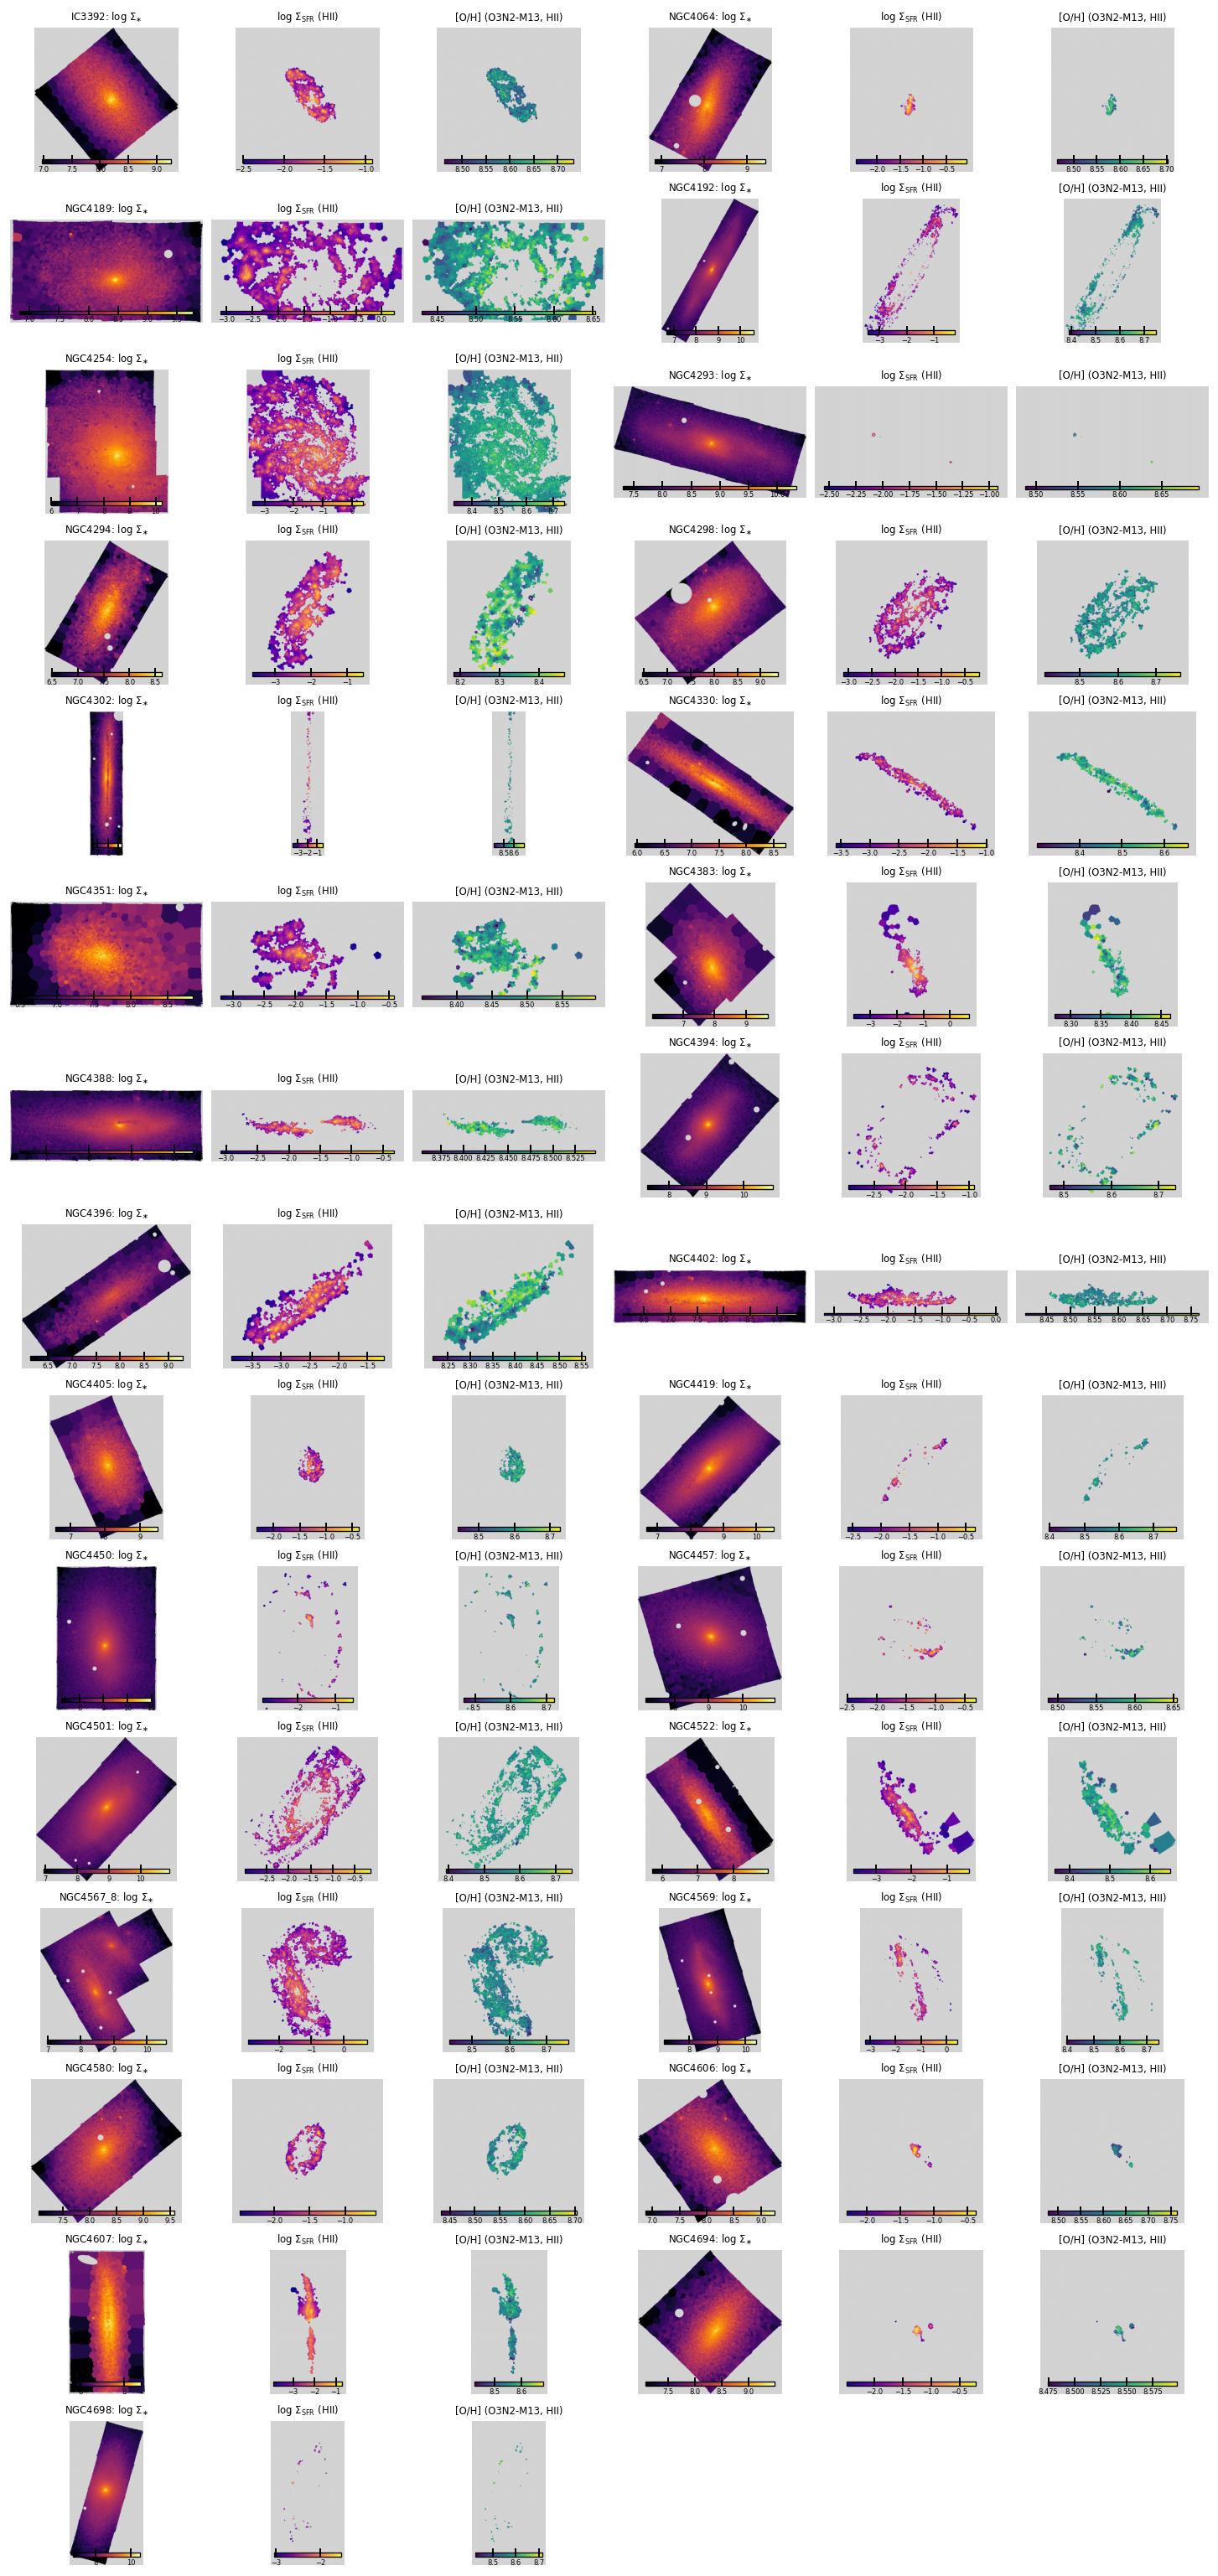

In [6]:
if old_paper_cells_ready(require_ew=True):
    # --------------------------------------------------------------
    # Maps: Σ_M*, Σ_SFR and [O/H] (O3N2-M13) maps for each galaxy
    # Using HII spaxels (common HII for Σ_SFR and O/H only)
    # Layout: dynamic rows, two 3-column galaxy blocks per row
    # Columns per row: [Σ_M*, Σ_SFR, [O/H]] × 2 blocks
    # --------------------------------------------------------------
    import math
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from pathlib import Path
    from astropy.io import fits

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0


    # 0 · discover galaxies
    galaxies = physics_ready_galaxies(require_ew=True)
    ngal     = len(galaxies)
    if ngal == 0:
        print("No galaxies with mass, SFR, O/H, and EW maps are ready yet.")

    # 1 · helpers to load maps (no mask for mass; HII mask for Σ_SFR and O/H)
    def load_maps_hii(gal):
        """
        Load stellar-mass surface density (from spatial-binning file),
        Σ_SFR (HII), and [O/H] (O3N2-M13, HII) for a galaxy.

        - Σ_M* is shown wherever it is finite (no HII mask).
        - Σ_SFR and [O/H] use a common HII mask requiring both to be finite.
        """
        with fits.open(further_spatial_path(gal)) as h_bin:
            logSigmaM = h_bin['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(further_gas_path(gal)) as h_gas:
            sigSFR_HII     = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
            ha_sigma_obs = h_gas['HA6562_SIGMA'].data
            ha_sigma_corr = h_gas['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h_gas else None
            if ha_sigma_corr is None:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in current further gas product')
            if ha_sigma_corr.shape != ha_sigma_obs.shape:
                raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {ha_sigma_corr.shape} vs SIGMA {ha_sigma_obs.shape}')
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            oh_o3n2m13_HII = h_gas['O_H_O3N2_M13_HII'].data

        ew_file = further_ew_path(gal, EW_FILE_SUFFIX)
        with fits.open(ew_file) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f"Missing {EW_HDU} in {ew_file}")
            ew_ha = h_ew[EW_HDU].data
        ew_ha = align_map_to_shape(ew_ha, sigSFR_HII.shape, label=f"{gal} {EW_HDU}")

        # Mass: just require Σ_M* to be finite
        mass_mask   = np.isfinite(logSigmaM)
        logSigmaM_c = np.where(mass_mask, logSigmaM, np.nan)

        # HII common mask for Σ_SFR and O/H
        hii_mask        = (np.isfinite(sigSFR_HII) & np.isfinite(oh_o3n2m13_HII) & np.isfinite(ew_ha) & (ew_ha > EW_MIN))
        hii_mask = hii_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR_HII_c    = np.where(hii_mask, sigSFR_HII, np.nan)
        oh_o3n2m13_c    = np.where(hii_mask, oh_o3n2m13_HII, np.nan)

        return logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c

    # 2 · figure & GridSpec  (two 3-column blocks per row)
    # Use constrained_layout for better handling of colorbars and spacing
    nrows = max(1, math.ceil(ngal / 2))
    fig = plt.figure(figsize=(12, max(3.0, 1.7 * nrows)), constrained_layout=True)
    gs  = GridSpec(
            nrows=nrows, ncols=6, figure=fig,
            width_ratios=[1, 1, 1, 1, 1, 1],      # [Σ_M*, Σ_SFR, [O/H]] × 2 blocks
            wspace=0.00, hspace=0.00
    )

    for idx, gal in enumerate(galaxies):
        row  = idx // 2                     # dynamic row index
        blk  = idx % 2                      # 0 or 1   (left / right 3-column block)
        col0 = blk * 3                      # 0 or 3   (start col of that block)

        logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c = load_maps_hii(gal)

        # Σ_M* map with NaN shown as light gray
        axM = fig.add_subplot(gs[row, col0])
        cmap_M = plt.cm.inferno.copy(); cmap_M.set_bad('lightgray')
        imM = axM.imshow(logSigmaM_c, origin='lower', cmap=cmap_M)
        axM.set_title(rf'{gal}: $\log\,\Sigma_{{\ast}}$', fontsize=7)
        axM.axis('off')
        caxM = inset_axes(axM, width='90%', height='3%', loc='lower center', borderpad=0.6)
        fig.colorbar(imM, cax=caxM, orientation='horizontal')
        caxM.tick_params(labelsize=5, pad=1)

        # Σ_SFR (HII) map with NaN shown as light gray
        axS = fig.add_subplot(gs[row, col0+1])
        cmap_S = plt.cm.plasma.copy(); cmap_S.set_bad('lightgray')
        imS = axS.imshow(sigSFR_HII_c, origin='lower', cmap=cmap_S)
        axS.set_title(r'$\log\,\Sigma_{\mathrm{SFR}}$ (HII)', fontsize=7)
        axS.axis('off')
        caxS = inset_axes(axS, width='90%', height='3%', loc='lower center', borderpad=0.6)
        fig.colorbar(imS, cax=caxS, orientation='horizontal')
        caxS.tick_params(labelsize=5, pad=1)

        # [O/H] O3N2-M13 (HII) map with NaN shown as light gray
        axOH = fig.add_subplot(gs[row, col0+2])
        cmap_OH = plt.cm.viridis.copy(); cmap_OH.set_bad('lightgray')
        imOH = axOH.imshow(oh_o3n2m13_c, origin='lower', cmap=cmap_OH)
        axOH.set_title(r'[O/H] (O3N2-M13, HII)', fontsize=7)
        axOH.axis('off')
        caxOH = inset_axes(axOH, width='90%', height='3%', loc='lower center', borderpad=0.6)
        fig.colorbar(imOH, cax=caxOH, orientation='horizontal')
        caxOH.tick_params(labelsize=5, pad=1)

    # Save figure in both PNG and PDF formats
    # Add a little extra space below plots via pad_inches
    # fig.savefig('Plot_Paper_1/MAUVE_MUSE_SigmaM_SigmaSFR_OH_Maps_HII_6x7_EW.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
    # fig.savefig('Plot_Paper_1/MAUVE_MUSE_SigmaM_SigmaSFR_OH_Maps_HII_6x7_EW.pdf', dpi=600, pad_inches=0.05)

    plt.show()
else:
    print("Skipped copied previous-project analysis cell 4: no nested *_further mass/SFR/OH+EW products are ready yet.")


### Source cell 14 BPT reproduction

  IC3392: 21521 valid spaxels (flux+SFR+EW mask)
  NGC4064: 22962 valid spaxels (flux+SFR+EW mask)
  NGC4189: 138857 valid spaxels (flux+SFR+EW mask)
  NGC4192: 352742 valid spaxels (flux+SFR+EW mask)
  NGC4254: 875496 valid spaxels (flux+SFR+EW mask)
  NGC4293: 14949 valid spaxels (flux+SFR+EW mask)
  NGC4294: 125907 valid spaxels (flux+SFR+EW mask)
  NGC4298: 229176 valid spaxels (flux+SFR+EW mask)
  NGC4302: 60720 valid spaxels (flux+SFR+EW mask)
  NGC4330: 87022 valid spaxels (flux+SFR+EW mask)
  NGC4351: 74644 valid spaxels (flux+SFR+EW mask)
  NGC4383: 37905 valid spaxels (flux+SFR+EW mask)
  NGC4388: 29104 valid spaxels (flux+SFR+EW mask)
  NGC4394: 84579 valid spaxels (flux+SFR+EW mask)
  NGC4396: 168505 valid spaxels (flux+SFR+EW mask)
  NGC4402: 117883 valid spaxels (flux+SFR+EW mask)
  NGC4405: 25767 valid spaxels (flux+SFR+EW mask)
  NGC4419: 29439 valid spaxels (flux+SFR+EW mask)
  NGC4450: 106818 valid spaxels (flux+SFR+EW mask)
  NGC4457: 63393 valid spaxels (flux+SFR+EW

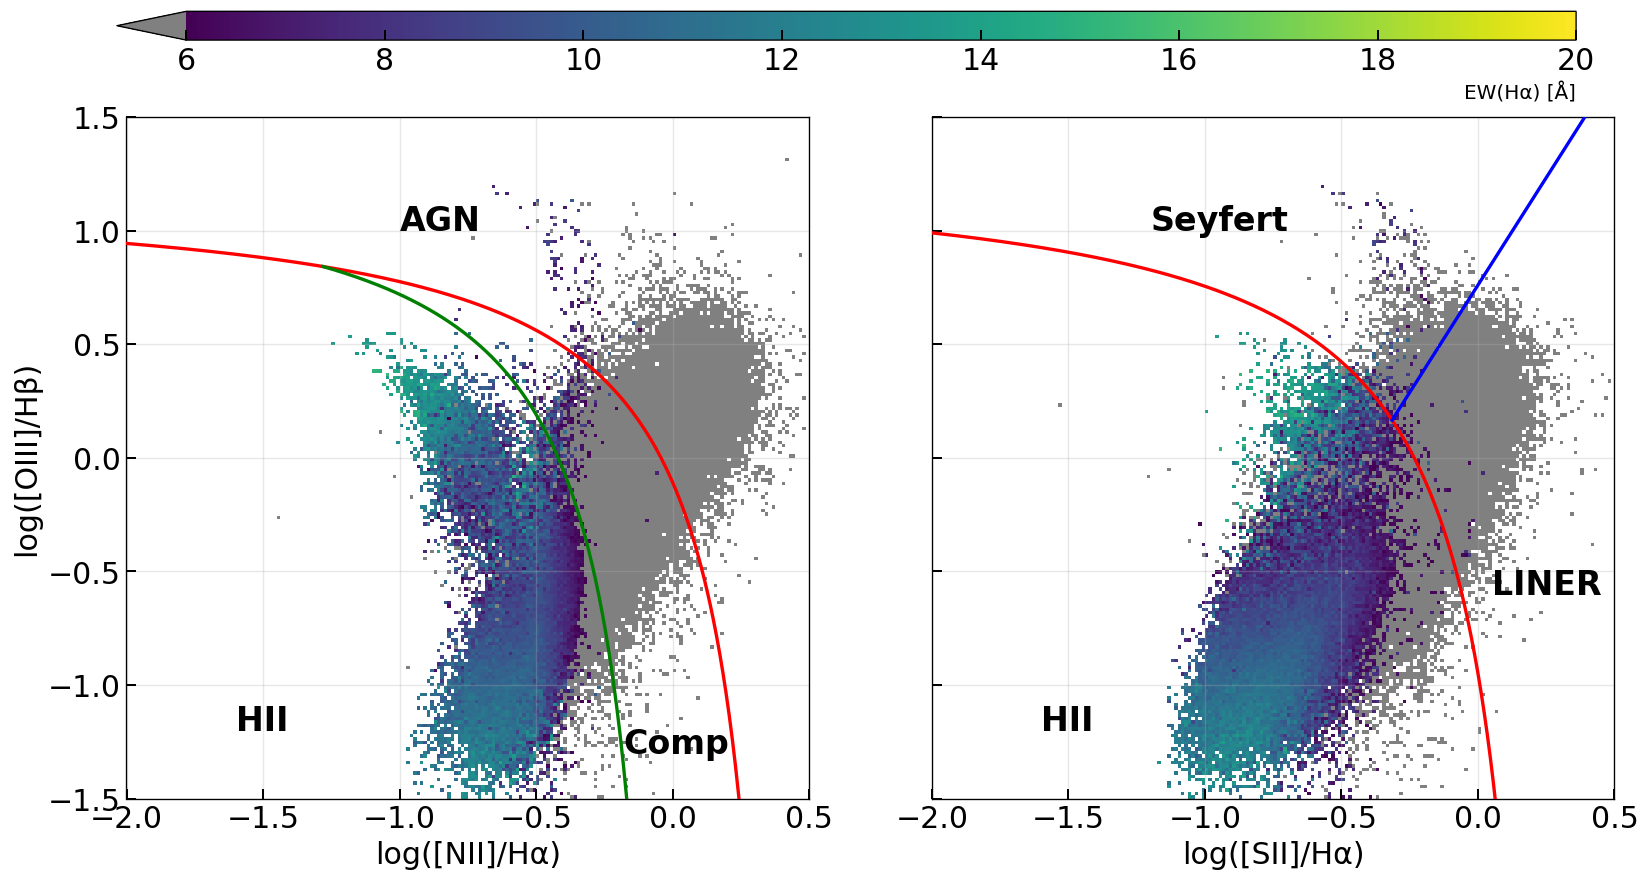


Successfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))
Galaxies included: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698


In [7]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Combined Analysis: NII and SII diagrams - color by EW(Halpha)
    # Collect all spaxels from all galaxies (no HII-only selection)
    # Use only dust-corrected emission line fluxes; no O/H needed
    # Apply SFR mask: keep spaxels with finite LOGSFR_SURFACE_DENSITY_HII,
    #                  LOGSFR_SURFACE_DENSITY_NONHII, or LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2
    # ------------------------------------------------------------------
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    from pathlib import Path
    from astropy.io import fits


    # BPT reference line functions (for drawing curves only, if desired)
    def kewley01_N2(x):   # max-starburst
        return 0.61/(x-0.47) + 1.19


    def kauff03_N2(x):    # empirical SF upper envelope
        return 0.61/(x-0.05) + 1.30


    def kewley01_S2(x):
        return 0.72/(x-0.32) + 1.30


    def kewley06_Sy_LIN(x):   # Seyfert/LINER division
        return 1.89*x + 0.76


    # Error propagation for BPT ratios (log10 numerator/denominator)
    def bpt_error_propagation(numerator, denominator, numerator_err, denominator_err):
        with np.errstate(divide='ignore', invalid='ignore'):
            log_ratio_err = 1/(np.log(10)) * np.sqrt((numerator_err / numerator)**2 + (denominator_err / denominator)**2)
            return log_ratio_err


    # Create x arrays for the theoretical lines (optional overlay)
    x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
    x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
    x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
    x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)


    # Get all galaxies from binning files
    galaxies = physics_ready_galaxies(require_ew=True)

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    SIGMA_CONTOUR_MAX = 45.0


    # Collect all spaxels from all galaxies (no HII selection)
    all_logN2 = []
    all_logO3 = []
    all_logS2 = []
    all_ew = []

    # Stats for SFR components
    count_hii = 0
    count_nonhii = 0
    count_unclass = 0
    count_union = 0
    sum_check_total = 0
    sum_check_ok = 0
    sum_check_maxabs = []

    # Stats for SF/NONSF/UNCLASSIFIED1 components
    count_sf = 0
    count_nonsf = 0
    count_unclass1 = 0
    count_union_sf = 0

    selection_rows = []
    total_base_c1 = 0
    total_hii_only = 0
    total_hii_ew6 = 0
    total_hii_ew6_sigma = 0

    # Error arrays for spaxel subsets
    err_hii_logN2, err_hii_logS2, err_hii_logO3 = [], [], []
    err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3 = [], [], []
    err_unclass_logN2, err_unclass_logS2, err_unclass_logO3 = [], [], []
    err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3 = [], [], []
    err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3 = [], [], []

    print('Collecting all spaxels from all galaxies (using corrected fluxes + EW, with SFR mask)...')
    for gal in galaxies:
        gas_file = further_gas_path(gal)
        bin_file = further_spatial_path(gal)
        ew_file = further_ew_path(gal, EW_FILE_SUFFIX)

        if gas_file.exists() and bin_file.exists() and ew_file.exists():
            with fits.open(gas_file) as h:
                # Load corrected emission line fluxes
                HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
                HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
                OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
                NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
                SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
                SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

                # Load corrected emission line flux errors
                HB4861_FLUX_ERR = h['HB4861_FLUX_ERR'].data
                HA6562_FLUX_ERR = h['HA6562_FLUX_ERR'].data
                OIII5006_FLUX_ERR = h['OIII5006_FLUX_ERR'].data
                NII6583_FLUX_ERR = h['NII6583_FLUX_ERR'].data
                SII6716_FLUX_ERR = h['SII6716_FLUX_ERR'].data
                SII6730_FLUX_ERR = h['SII6730_FLUX_ERR'].data

                # Load SFR surface density maps
                logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
                logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data
                logSigmaSFR_UNCLASS = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2'].data
                logSigmaSFR_TOTAL = h['LOGSFR_SURFACE_DENSITY'].data

                # Load SF / NONSF / UNCLASSIFIED1 maps
                logSigmaSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
                logSigmaSFR_NONSF = h['LOGSFR_SURFACE_DENSITY_NONSF'].data
                logSigmaSFR_UNCLASS1 = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED1'].data
                HA6562_SIGMA_OBS = h['HA6562_SIGMA'].data
                HA6562_SIGMA_CORR = h['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h else None
                if HA6562_SIGMA_CORR is None:
                    raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_file.name}')
                if HA6562_SIGMA_CORR.shape != HA6562_SIGMA_OBS.shape:
                    raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {HA6562_SIGMA_CORR.shape} vs SIGMA {HA6562_SIGMA_OBS.shape}')
                sigma2_intrinsic = HA6562_SIGMA_OBS**2 - HA6562_SIGMA_CORR**2
                HA6562_SIGMA = np.full_like(HA6562_SIGMA_OBS, np.nan, dtype=float)
                sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
                HA6562_SIGMA[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])

            with fits.open(ew_file) as h_ew:
                if EW_HDU not in h_ew:
                    print(f'  {gal}: missing EW HDU {EW_HDU} in {ew_file.name}')
                    continue
                ew_ha = h_ew[EW_HDU].data

            ew_ha = align_map_to_shape(ew_ha, HA6562_FLUX_corr.shape, label=f"{gal} {EW_HDU}")

            # SFR masks
            hii_mask = np.isfinite(logSigmaSFR_HII)
            nonhii_mask = np.isfinite(logSigmaSFR_NONHII)
            unclass_mask = np.isfinite(logSigmaSFR_UNCLASS)
            total_mask = np.isfinite(logSigmaSFR_TOTAL)
            union_mask = hii_mask | nonhii_mask | unclass_mask

            count_hii += np.sum(hii_mask)
            count_nonhii += np.sum(nonhii_mask)
            count_unclass += np.sum(unclass_mask)
            count_union += np.sum(union_mask)

            # SF / NONSF / UNCLASSIFIED1 masks
            sf_mask = np.isfinite(logSigmaSFR_SF)
            nonsf_mask = np.isfinite(logSigmaSFR_NONSF)
            unclass1_mask = np.isfinite(logSigmaSFR_UNCLASS1)
            union_sf_mask = sf_mask | nonsf_mask | unclass1_mask

            count_sf += np.sum(sf_mask)
            count_nonsf += np.sum(nonsf_mask)
            count_unclass1 += np.sum(unclass1_mask)
            count_union_sf += np.sum(union_sf_mask)

            # Check add-up consistency where all components and total are finite
            sum_mask = hii_mask & nonhii_mask & unclass_mask & total_mask
            if np.any(sum_mask):
                diff = logSigmaSFR_TOTAL[sum_mask] - (
                    logSigmaSFR_HII[sum_mask] + logSigmaSFR_NONHII[sum_mask] + logSigmaSFR_UNCLASS[sum_mask]
                )
                sum_check_total += diff.size
                sum_check_ok += np.sum(np.isclose(diff, 0.0, atol=1e-6, rtol=0))
                sum_check_maxabs.append(np.nanmax(np.abs(diff)))

            # Valid where all corrected line fluxes are finite and positive
            flux_mask = (
                np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &
                np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &
                np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &
                np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &
                np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &
                np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)
            )

            # SFR mask: keep spaxels where any class is finite
            sfr_mask = union_mask

            # EW mask
            ew_mask = np.isfinite(ew_ha) & (ew_ha > 0)
            ew_mask = ew_mask & np.isfinite(HA6562_SIGMA) & (HA6562_SIGMA < 45.0)

            base_c1_mask = flux_mask & union_mask & np.isfinite(ew_ha) & (ew_ha > 0) & np.isfinite(HA6562_SIGMA_CORR) & (HA6562_SIGMA_CORR > 0)
            hii_only_mask = base_c1_mask & np.isfinite(logSigmaSFR_HII)
            hii_ew6_mask = hii_only_mask & np.isfinite(ew_ha) & (ew_ha > 6.0)
            hii_ew6_sigma_mask = hii_ew6_mask & np.isfinite(HA6562_SIGMA) & (HA6562_SIGMA < 45.0)

            n_base_c1 = int(np.sum(base_c1_mask))
            n_hii_only = int(np.sum(hii_only_mask))
            n_hii_ew6 = int(np.sum(hii_ew6_mask))
            n_hii_ew6_sigma = int(np.sum(hii_ew6_sigma_mask))
            selection_rows.append((gal, n_base_c1, n_hii_only, n_hii_ew6, n_hii_ew6_sigma))
            total_base_c1 += n_base_c1
            total_hii_only += n_hii_only
            total_hii_ew6 += n_hii_ew6
            total_hii_ew6_sigma += n_hii_ew6_sigma

            # Combined mask for plotting
            valid_mask = flux_mask & sfr_mask & ew_mask
            n_pixels = np.sum(valid_mask)
            print(f'  {gal}: {n_pixels} valid spaxels (flux+SFR+EW mask)')

            HB_common = HB4861_FLUX_corr[valid_mask]
            HA_common = HA6562_FLUX_corr[valid_mask]
            OIII_common = OIII5006_FLUX_corr[valid_mask]
            NII_common = NII6583_FLUX_corr[valid_mask]
            SII6716_common = SII6716_FLUX_corr[valid_mask]
            SII6730_common = SII6730_FLUX_corr[valid_mask]
            EW_common = ew_ha[valid_mask]

            # Calculate line ratios for all valid spaxels
            logN2 = np.log10(NII_common / HA_common)
            logO3 = np.log10(OIII_common / HB_common)
            logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)

            all_logN2.extend(logN2.flatten())
            all_logO3.extend(logO3.flatten())
            all_logS2.extend(logS2.flatten())
            all_ew.extend(EW_common.flatten())

            # Error propagation for spaxel subsets
            err_mask = (
                np.isfinite(HB4861_FLUX_ERR) & (HB4861_FLUX_ERR > 0) &
                np.isfinite(HA6562_FLUX_ERR) & (HA6562_FLUX_ERR > 0) &
                np.isfinite(OIII5006_FLUX_ERR) & (OIII5006_FLUX_ERR > 0) &
                np.isfinite(NII6583_FLUX_ERR) & (NII6583_FLUX_ERR > 0) &
                np.isfinite(SII6716_FLUX_ERR) & (SII6716_FLUX_ERR > 0) &
                np.isfinite(SII6730_FLUX_ERR) & (SII6730_FLUX_ERR > 0)
            )

            def collect_errs(sub_mask, out_N2, out_S2, out_O3):
                valid_err_mask = flux_mask & err_mask & ew_mask & sub_mask
                if np.any(valid_err_mask):
                    hb = HB4861_FLUX_corr[valid_err_mask]
                    ha = HA6562_FLUX_corr[valid_err_mask]
                    o3 = OIII5006_FLUX_corr[valid_err_mask]
                    n2 = NII6583_FLUX_corr[valid_err_mask]
                    s2_1 = SII6716_FLUX_corr[valid_err_mask]
                    s2_2 = SII6730_FLUX_corr[valid_err_mask]

                    hb_err = HB4861_FLUX_ERR[valid_err_mask]
                    ha_err = HA6562_FLUX_ERR[valid_err_mask]
                    o3_err = OIII5006_FLUX_ERR[valid_err_mask]
                    n2_err = NII6583_FLUX_ERR[valid_err_mask]
                    s2_1_err = SII6716_FLUX_ERR[valid_err_mask]
                    s2_2_err = SII6730_FLUX_ERR[valid_err_mask]

                    s2 = s2_1 + s2_2
                    s2_err = np.sqrt(s2_1_err**2 + s2_2_err**2)

                    err_logN2 = bpt_error_propagation(n2, ha, n2_err, ha_err)
                    err_logS2 = bpt_error_propagation(s2, ha, s2_err, ha_err)
                    err_logO3 = bpt_error_propagation(o3, hb, o3_err, hb_err)

                    out_N2.extend(err_logN2[np.isfinite(err_logN2)])
                    out_S2.extend(err_logS2[np.isfinite(err_logS2)])
                    out_O3.extend(err_logO3[np.isfinite(err_logO3)])

            collect_errs(hii_mask, err_hii_logN2, err_hii_logS2, err_hii_logO3)
            collect_errs(nonhii_mask, err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3)
            collect_errs(unclass_mask, err_unclass_logN2, err_unclass_logS2, err_unclass_logO3)
            collect_errs(hii_mask | nonhii_mask, err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3)
            collect_errs(union_mask, err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3)
        else:
            missing_parts = []
            if not gas_file.exists():
                missing_parts.append(gas_file.name)
            if not bin_file.exists():
                missing_parts.append(bin_file.name)
            if not ew_file.exists():
                missing_parts.append(ew_file.name)
            print(f"  {gal}: Missing files -> {', '.join(missing_parts)}")

    # Convert to numpy arrays
    all_logN2 = np.array(all_logN2)
    all_logO3 = np.array(all_logO3)
    all_logS2 = np.array(all_logS2)
    all_ew = np.array(all_ew)

    if len(all_logN2) == 0:
        raise RuntimeError('No valid spaxels found after applying flux+SFR+EW masks.')
    if len(all_ew) != len(all_logN2):
        raise RuntimeError('EW array length mismatch with BPT arrays.')

    # Report SFR component stats
    print(f'\nTotal combined valid spaxels (flux+SFR+EW mask): {len(all_logN2)}')
    if count_union > 0:
        print('\nSFR component counts (finite spaxels, all galaxies combined):')
        print(f'  HII: {count_hii} ({count_hii / count_union * 100:.3f}%)')
        print(f'  NONHII: {count_nonhii} ({count_nonhii / count_union * 100:.3f}%)')
        print(f'  UNCLASSIFIED2: {count_unclass} ({count_unclass / count_union * 100:.3f}%)')

    if count_union > 0:
        print('\nSF component counts (finite spaxels, all galaxies combined):')
        print(f'  SF: {count_sf} ({count_sf / count_union * 100:.3f}%)')
        print(f'  NONSF: {count_nonsf} ({count_nonsf / count_union * 100:.3f}%)')
        print(f'  UNCLASSIFIED1: {count_unclass1} ({count_unclass1 / count_union * 100:.3f}%)')

    if sum_check_total > 0:
        max_abs_diff = np.nanmax(sum_check_maxabs) if len(sum_check_maxabs) > 0 else np.nan
        print('\nCheck LOGSFR_SURFACE_DENSITY ≈ HII + NONHII + UNCLASSIFIED2 (finite spaxels):')
        print(f'  Passed: {sum_check_ok} / {sum_check_total} ({sum_check_ok / sum_check_total:.3f})')
        print(f'  Max |Δ|: {max_abs_diff:.3e}')

    def frac(numerator, denominator):
        return np.nan if denominator == 0 else numerator / denominator

    print('\nSelection chain (per galaxy):')
    print('  Base(Cell1) -> HII -> HII+EW>6 -> HII+EW>6+sigma_int<45')
    header_sel = (
        f"{'Galaxy':<10} {'Base(C1)':>10} {'HII':>10} {'f(HII)':>10} "
        f"{'HII+EW>6':>12} {'f(HII+EW)':>12} {'HII+EW+sig<45':>16} {'f(final)':>10}"
    )
    print(header_sel)
    print('-' * len(header_sel))
    for gal_sel, n_base_sel, n_hii_sel, n_hii_ew_sel, n_hii_ew_sig_sel in selection_rows:
        print(
            f"{gal_sel:<10} {n_base_sel:10d} {n_hii_sel:10d} {frac(n_hii_sel, n_base_sel):10.4f} "
            f"{n_hii_ew_sel:12d} {frac(n_hii_ew_sel, n_base_sel):12.4f} {n_hii_ew_sig_sel:16d} {frac(n_hii_ew_sig_sel, n_base_sel):10.4f}"
        )
    print('-' * len(header_sel))
    print(
        f"{'ALL':<10} {total_base_c1:10d} {total_hii_only:10d} {frac(total_hii_only, total_base_c1):10.4f} "
        f"{total_hii_ew6:12d} {frac(total_hii_ew6, total_base_c1):12.4f} {total_hii_ew6_sigma:16d} {frac(total_hii_ew6_sigma, total_base_c1):10.4f}"
    )

    # Mean log-errors for requested subsets

    def mean_or_nan(arr):
        return np.nanmean(arr) if len(arr) > 0 else np.nan

    print('\nMean log-error (spaxel subsets):')
    print(f'  HII only       - log([NII]/Hα): {mean_or_nan(err_hii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_logO3):.4f}')
    print(f'  NONHII only    - log([NII]/Hα): {mean_or_nan(err_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_nonhii_logO3):.4f}')
    print(f'  UNCLASS only   - log([NII]/Hα): {mean_or_nan(err_unclass_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_unclass_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_unclass_logO3):.4f}')
    print(f'  HII+NONHII     - log([NII]/Hα): {mean_or_nan(err_hii_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_nonhii_logO3):.4f}')
    print(f'  HII+NONHII+UNC - log([NII]/Hα): {mean_or_nan(err_allclasses_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_allclasses_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_allclasses_logO3):.4f}')

    # Create diagrams for all spaxels (2D EW color)
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
    plt.subplots_adjust(wspace=0.18, top=0.82)

    import copy

    cmap_ew = copy.copy(plt.get_cmap('viridis'))
    cmap_ew.set_under('grey')

    # Binning and ranges
    xlim = (-2.0, 0.5)
    ylim = (-1.5, 1.5)
    bins_2d = 200
    min_count_per_bin = 3
    vmin_ew = 6.0
    vmax_ew = 20.0

    # NII panel EW grid
    hist_N2, xedges_N2, yedges_N2 = np.histogram2d(
        all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim]
    )
    sum_ew_N2, _, _ = np.histogram2d(
        all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
    )
    mean_ew_N2 = np.divide(
        sum_ew_N2,
        hist_N2,
        out=np.full_like(sum_ew_N2, np.nan, dtype=float),
        where=hist_N2 > 0,
    )
    mean_ew_N2[hist_N2 < min_count_per_bin] = np.nan

    # SII panel EW grid
    hist_S2, xedges_S2, yedges_S2 = np.histogram2d(
        all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim]
    )
    sum_ew_S2, _, _ = np.histogram2d(
        all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
    )
    mean_ew_S2 = np.divide(
        sum_ew_S2,
        hist_S2,
        out=np.full_like(sum_ew_S2, np.nan, dtype=float),
        where=hist_S2 > 0,
    )
    mean_ew_S2[hist_S2 < min_count_per_bin] = np.nan

    # NII diagram
    ax = axes[0]
    img_N2 = ax.pcolormesh(
        xedges_N2,
        yedges_N2,
        np.ma.masked_invalid(mean_ew_N2.T),
        cmap=cmap_ew,
        vmin=vmin_ew,
        vmax=vmax_ew,
        shading='auto',
        edgecolors='face',
        linewidths=0
    )

    # Optional: overlay BPT curves as reference only
    ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)
    ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)

    ax.set_xlabel('log([NII]/Hα)', fontsize=18)
    ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
    ax.text(-0.18, -1.3, 'Comp', fontsize=20, fontweight='bold')
    ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # SII diagram
    ax = axes[1]
    img_S2 = ax.pcolormesh(
        xedges_S2,
        yedges_S2,
        np.ma.masked_invalid(mean_ew_S2.T),
        cmap=cmap_ew,
        vmin=vmin_ew,
        vmax=vmax_ew,
        shading='auto',
        edgecolors='face',
        linewidths=0
    )

    ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)
    ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)

    ax.set_xlabel('log([SII]/Hα)', fontsize=18)
    ax.set_ylabel('')
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='y', labelleft=False)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
    ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')
    ax.text(0.05, -0.6, 'LINER', fontsize=20, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Shared colorbar (top, spanning both panels)
    cax = fig.add_axes([0.12, 0.9, 0.76, 0.03])
    cbar = fig.colorbar(img_N2, cax=cax, orientation='horizontal', extend='min')
    cbar.set_label('EW(Hα) [Å]', fontsize=12, loc='right')
    cbar.ax.tick_params(labelsize=18)

    # Save figures
    output_dir = Path('Plot_Paper_1')
    output_dir.mkdir(parents=True, exist_ok=True)
    # fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.png', dpi=600, bbox_inches='tight')
    # fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.pdf', bbox_inches='tight')
    plt.show()

    print('\nSuccessfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))')
    print('Galaxies included: ' + ', '.join(galaxies))
else:
    print("Skipped copied previous-project analysis cell 3: no nested *_further mass/SFR/OH+EW products are ready yet.")


### Source cell 26 reproduction

  IC3392: common HII pixels with EW(Ha)>6 Å = 10750
  NGC4064: common HII pixels with EW(Ha)>6 Å = 4690
  NGC4189: common HII pixels with EW(Ha)>6 Å = 80496
  NGC4192: common HII pixels with EW(Ha)>6 Å = 123112
  NGC4254: common HII pixels with EW(Ha)>6 Å = 645936
  NGC4293: common HII pixels with EW(Ha)>6 Å = 329
  NGC4294: common HII pixels with EW(Ha)>6 Å = 67487
  NGC4298: common HII pixels with EW(Ha)>6 Å = 104274
  NGC4302: common HII pixels with EW(Ha)>6 Å = 19859
  NGC4330: common HII pixels with EW(Ha)>6 Å = 28309
  NGC4351: common HII pixels with EW(Ha)>6 Å = 26425
  NGC4383: excluded from analysis
  NGC4388: common HII pixels with EW(Ha)>6 Å = 17979
  NGC4394: common HII pixels with EW(Ha)>6 Å = 17856
  NGC4396: common HII pixels with EW(Ha)>6 Å = 83349
  NGC4402: common HII pixels with EW(Ha)>6 Å = 35583
  NGC4405: common HII pixels with EW(Ha)>6 Å = 10135
  NGC4419: common HII pixels with EW(Ha)>6 Å = 4025
  NGC4450: common HII pixels with EW(Ha)>6 Å = 12062
  NGC4457: com

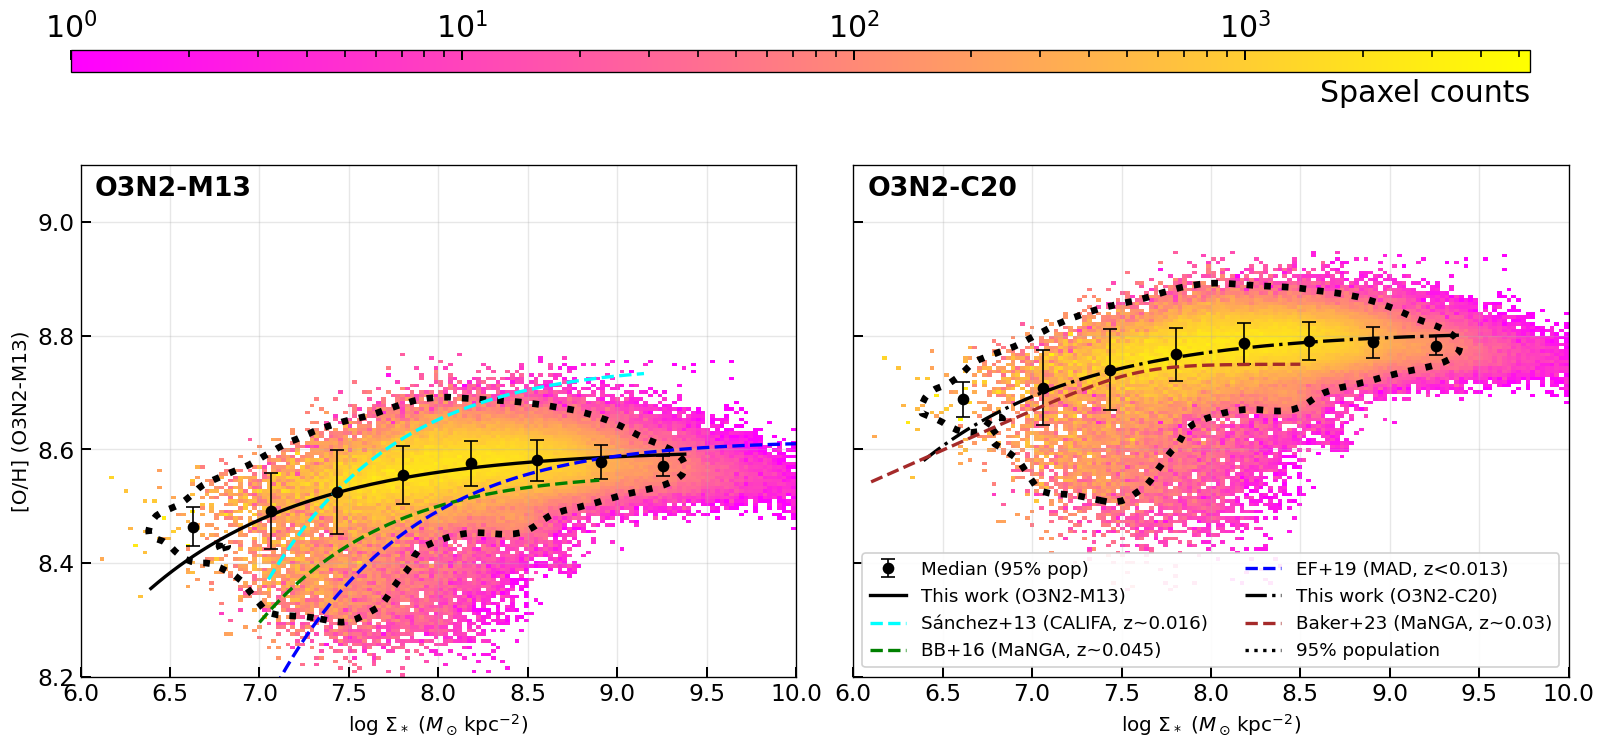


COMPLETED: Two-panel rMZR comparison (O3N2-M13 vs O3N2-C20)
Output PNG: Plot_Paper_1/MAUVE_MUSE_rMZR_O3N2M13_vs_C20_counts_EW.png
Output PDF: Plot_Paper_1/MAUVE_MUSE_rMZR_O3N2M13_vs_C20_counts_EW.pdf
Galaxies included: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Excluded: NGC4383

Final sample:
  Number of common HII spaxels: 1795602
  EW(Ha) cut: > 6 Å


In [8]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # rMZR comparison: O3N2-M13 vs O3N2-C20 (HII only)
    #
    # Two-panel layout:
    #   Left : rMZR 2D histogram (O3N2-M13) with literature curves
    #   Right: rMZR 2D histogram (O3N2-C20) with Baker+23 curve
    #
    # Important fix:
    #   M13 and C20 are now selected with the SAME common spaxel mask:
    #       finite(logSigmaM) &
    #       finite(O/H_M13) &
    #       finite(O/H_C20) &
    #       finite(EW_Ha) &
    #       EW_Ha > EW_MIN
    #
    # This guarantees:
    #       logSigmaM[i], O/H_M13[i], O/H_C20[i]
    #   are from the same physical spaxel.
    # ------------------------------------------------------------------

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    from matplotlib.lines import Line2D
    from pathlib import Path
    from astropy.io import fits

    import scipy.ndimage as ndimage
    from scipy.optimize import curve_fit


    # ------------------------------------------------------------------
    # Config
    # ------------------------------------------------------------------

    EW_FILE_SUFFIX = "_proxy_EW_maps.fits"
    EW_HDU = "PROXY_EWHA"
    EW_MIN = 6.0

    EXCLUDED_GALAXIES = {"NGC4383"}

    OUTDIR = Path("Plot_Paper_1")
    OUTDIR.mkdir(parents=True, exist_ok=True)

    OUTPNG = OUTDIR / "MAUVE_MUSE_rMZR_O3N2M13_vs_C20_counts_EW.png"
    OUTPDF = OUTDIR / "MAUVE_MUSE_rMZR_O3N2M13_vs_C20_counts_EW.pdf"

    COMMON_YLIM = (8.2, 9.1)
    XRANGE_RMZR = (6.0, 10.0)

    NBINS_HIST = 150
    NBINS_DENSITY = 100
    DENSITY_SIGMA = 2.0

    BIN_WIDTH = 0.4
    MIN_PIXELS_PER_BIN = 20


    # ------------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------------

    def require_hdu(hdul, hdu_name, filename):
        """Raise a clear error if a required HDU is missing."""
        if hdu_name not in hdul:
            raise KeyError(f"Missing HDU '{hdu_name}' in {filename}")
        return hdul[hdu_name].data


    def load_maps(gal):
        """Load stellar mass surface density and both O3N2 metallicity maps."""
        bin_file = further_spatial_path(gal)
        gas_file = further_gas_path(gal)
        ew_file = further_ew_path(gal, EW_FILE_SUFFIX)

        if not bin_file.exists():
            raise FileNotFoundError(f"Missing file: {bin_file}")
        if not gas_file.exists():
            raise FileNotFoundError(f"Missing file: {gas_file}")
        if not ew_file.exists():
            raise FileNotFoundError(f"Missing file: {ew_file}")

        with fits.open(bin_file) as h:
            logSigmaM = require_hdu(h, "LOGMASS_SURFACE_DENSITY", bin_file)

        with fits.open(gas_file) as h:
            oh_o3n2_m13 = require_hdu(h, "O_H_O3N2_M13_HII", gas_file)
            oh_o3n2_c20 = require_hdu(h, "O_H_O3N2_C20_HII", gas_file)

        with fits.open(ew_file) as h:
            ew_ha = require_hdu(h, EW_HDU, ew_file)
        ew_ha = align_map_to_shape(ew_ha, oh_o3n2_m13.shape, label=f"{gal} {EW_HDU}")

        return logSigmaM, oh_o3n2_m13, oh_o3n2_c20, ew_ha


    def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
        """
        Calculate median and standard deviation in x bins.

        Keeps only bins with at least min_pixels finite y-values.
        """
        finite = np.isfinite(x_data) & np.isfinite(y_data)
        x_data = np.asarray(x_data)[finite]
        y_data = np.asarray(y_data)[finite]

        if len(x_data) == 0:
            return (
                np.array([]),
                np.array([]),
                np.array([]),
                np.array([]),
                np.array([]),
            )

        x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)

        medians = []
        stds = []
        counts = []
        valid_centers = []
        valid_bin_indices = []

        for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
            in_bin = (x_data >= bin_start) & (x_data < bin_end)

            x_in_bin = x_data[in_bin]
            y_in_bin = y_data[in_bin]

            if np.sum(np.isfinite(y_in_bin)) >= min_pixels:
                valid_centers.append(np.nanmedian(x_in_bin))
                medians.append(np.nanmedian(y_in_bin))
                stds.append(np.nanstd(y_in_bin))
                counts.append(np.sum(np.isfinite(y_in_bin)))
                valid_bin_indices.append(i)

        return (
            np.asarray(valid_centers),
            np.asarray(medians),
            np.asarray(stds),
            np.asarray(counts),
            np.asarray(valid_bin_indices),
        )


    def mzr_model(x, a, b, c):
        """Sánchez-style rMZR functional form."""
        return a + b * (x - c) * np.exp(-(x - c))


    def compute_density_mask(
        x_vals,
        y_vals,
        x_range,
        y_range,
        nbins=100,
        sigma=2.0,
        return_contour=False,
    ):
        """
        Return mask for points inside the 95% density contour.

        The density is estimated from a smoothed 2D histogram in the requested range.
        """
        x_vals = np.asarray(x_vals)
        y_vals = np.asarray(y_vals)

        mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)

        empty_mask = np.zeros_like(x_vals, dtype=bool)

        if not np.any(mask_finite):
            if return_contour:
                return empty_mask, None, None
            return empty_mask

        x = x_vals[mask_finite]
        y = y_vals[mask_finite]

        H, xedges, yedges = np.histogram2d(
            x,
            y,
            bins=nbins,
            range=[x_range, y_range],
        )

        if np.sum(H) <= 0:
            if return_contour:
                return empty_mask, None, None
            return empty_mask

        H_smooth = ndimage.gaussian_filter(H, sigma=sigma)

        H_flat = np.sort(H_smooth.ravel())[::-1]
        H_cumsum = np.cumsum(H_flat)

        if H_cumsum[-1] <= 0:
            if return_contour:
                return empty_mask, None, None
            return empty_mask

        level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
        level_idx = min(level_idx, len(H_flat) - 1)
        level_95 = H_flat[level_idx]

        x_centers = 0.5 * (xedges[:-1] + xedges[1:])
        y_centers = 0.5 * (yedges[:-1] + yedges[1:])

        X, Y = np.meshgrid(x_centers, y_centers)

        dx = (x_range[1] - x_range[0]) / nbins
        dy = (y_range[1] - y_range[0]) / nbins

        x_idx = (x - x_range[0]) / dx - 0.5
        y_idx = (y - y_range[0]) / dy - 0.5

        densities = ndimage.map_coordinates(
            H_smooth,
            [x_idx, y_idx],
            order=1,
            mode="constant",
            cval=0.0,
        )

        mask_local = densities >= level_95

        full_mask = np.zeros_like(x_vals, dtype=bool)
        full_mask[np.where(mask_finite)[0]] = mask_local

        if return_contour:
            return full_mask, level_95, (X, Y, H_smooth)

        return full_mask


    def plot_literature_mzr_fits(ax, show_legend=True):
        """Overlay literature rMZR curves: Sánchez+13, Barrera-Ballesteros+16, Erroz-Ferrer+19."""
        plot_data = []

        x_sanchez = np.linspace(7.05, 9.15, 200)
        a5, b5, c5 = 8.74, 0.013, 9.50
        y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
        plot_data.append(
            (
                x_sanchez,
                y_sanchez13,
                "Sánchez+13 (CALIFA, z~0.016)",
                "--",
                "cyan",
            )
        )

        x_bb = np.linspace(7.0, 8.9, 200)
        a2, b2, c2 = 8.55, 0.014, 9.14
        y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
        plot_data.append(
            (
                x_bb,
                y_bb16,
                "BB+16 (MaNGA, z~0.045)",
                "--",
                "green",
            )
        )

        x_ef = np.linspace(6.5, 10.0, 200)
        a4, b4, c4 = 8.61, 0.008, 10.0
        y_ef19 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
        plot_data.append(
            (
                x_ef,
                y_ef19,
                "EF+19 (MAD, z<0.013)",
                "--",
                "blue",
            )
        )

        handles = []

        for x, y, label, linestyle, color in plot_data:
            line, = ax.plot(
                x,
                y,
                label=label if show_legend else None,
                linewidth=2,
                linestyle=linestyle,
                color=color,
            )
            handles.append(line)

        return handles


    def plot_literature_baker(ax, show_legend=True):
        """Overlay Baker+23 collapsed rFMR curve."""
        x_baker = np.linspace(6.1, 8.5, 200)

        logSigmaSFR_ref = -2.0

        Z0_B = 8.75
        gamma_B = 0.14
        phi_B = 2.73
        m0_B = 8.58
        m1_B = 0.50

        logM0_B = m0_B + m1_B * logSigmaSFR_ref
        M0_B = 10.0 ** logM0_B
        Sigma_star_B = 10.0 ** x_baker

        y_baker23 = Z0_B - (gamma_B / phi_B) * np.log10(
            1.0 + (Sigma_star_B / M0_B) ** (-phi_B)
        )

        line, = ax.plot(
            x_baker,
            y_baker23,
            label="Baker+23 (MaNGA, z~0.03)" if show_legend else None,
            linewidth=2,
            linestyle="--",
            color="brown",
        )

        return [line]


    def safe_fit_and_plot(ax, x, y, linestyle, label):
        """Fit mzr_model to x/y and plot the result."""
        finite = np.isfinite(x) & np.isfinite(y)
        x_fit_data = np.asarray(x)[finite]
        y_fit_data = np.asarray(y)[finite]

        if len(x_fit_data) < 10:
            print(f"{label}: not enough points for fitting.")
            return None, None, None, None

        p0 = [8.5, 0.0002, 12.5]
        bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])

        try:
            popt, pcov = curve_fit(
                mzr_model,
                x_fit_data,
                y_fit_data,
                p0=p0,
                bounds=bounds,
                maxfev=5000,
            )

            x_model = np.linspace(np.nanmin(x_fit_data), np.nanmax(x_fit_data), 150)
            y_model = mzr_model(x_model, *popt)

            line, = ax.plot(
                x_model,
                y_model,
                linestyle,
                linewidth=2,
                color="k",
                label=label,
            )

            perr = np.sqrt(np.diag(pcov))

            print(
                f"{label}: "
                f"a={popt[0]:.3f} ± {perr[0]:.3f}, "
                f"b={popt[1]:.5f} ± {perr[1]:.5f}, "
                f"c={popt[2]:.3f} ± {perr[2]:.3f}"
            )

            return line, popt, pcov, (x_model, y_model)

        except Exception as e:
            print(f"{label} fit failed: {e}")
            return None, None, None, None


    # ------------------------------------------------------------------
    # Collect data
    # ------------------------------------------------------------------

    galaxies = physics_ready_galaxies(require_ew=True)

    included_galaxies = []

    all_logSigmaM_HII = []
    all_oh_o3n2_m13_HII = []
    all_oh_o3n2_c20_HII = []

    print("=" * 80)
    print("Collecting common HII spaxels for O3N2-M13 and O3N2-C20...")
    print("=" * 80)

    for gal in galaxies:
        if gal in EXCLUDED_GALAXIES:
            print(f"  {gal}: excluded from analysis")
            continue

        try:
            logSigmaM, oh_o3n2_m13, oh_o3n2_c20, ew_ha = load_maps(gal)
        except Exception as e:
            print(f"  {gal}: skipped - {e}")
            continue

        shapes = {
            "logSigmaM": logSigmaM.shape,
            "O3N2-M13": oh_o3n2_m13.shape,
            "O3N2-C20": oh_o3n2_c20.shape,
            "EW(Ha)": ew_ha.shape,
        }

        if len(set(shapes.values())) != 1:
            print(f"  {gal}: skipped - shape mismatch: {shapes}")
            continue

        common_mask = (
            np.isfinite(logSigmaM)
            & np.isfinite(oh_o3n2_m13)
            & np.isfinite(oh_o3n2_c20)
            & np.isfinite(ew_ha)
            & (ew_ha > EW_MIN)
        )

        n_common = int(np.sum(common_mask))

        print(f"  {gal}: common HII pixels with EW(Ha)>{EW_MIN:g} Å = {n_common}")

        if n_common == 0:
            continue

        included_galaxies.append(gal)

        all_logSigmaM_HII.extend(logSigmaM[common_mask].ravel())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13[common_mask].ravel())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20[common_mask].ravel())


    all_logSigmaM_HII = np.asarray(all_logSigmaM_HII)
    all_oh_o3n2_m13_HII = np.asarray(all_oh_o3n2_m13_HII)
    all_oh_o3n2_c20_HII = np.asarray(all_oh_o3n2_c20_HII)

    print("\n" + "-" * 80)
    print("Final array lengths:")
    print(f"  logSigmaM   : {len(all_logSigmaM_HII)}")
    print(f"  O3N2-M13    : {len(all_oh_o3n2_m13_HII)}")
    print(f"  O3N2-C20    : {len(all_oh_o3n2_c20_HII)}")
    print("-" * 80)

    assert len(all_logSigmaM_HII) == len(all_oh_o3n2_m13_HII)
    assert len(all_logSigmaM_HII) == len(all_oh_o3n2_c20_HII)

    if len(all_logSigmaM_HII) == 0:
        raise RuntimeError("No common HII spaxels found. Check EW files, HDU names, and input maps.")


    # ------------------------------------------------------------------
    # Plot setup
    # ------------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
        sharex=True,
        sharey=True,
    )

    plt.subplots_adjust(wspace=0.08, top=0.82)

    ax_left, ax_right = axes


    # ------------------------------------------------------------------
    # Left panel: O3N2-M13
    # ------------------------------------------------------------------

    print("\n--- Left panel: O3N2-M13 rMZR ---")

    mask_m13 = np.isfinite(all_logSigmaM_HII) & np.isfinite(all_oh_o3n2_m13_HII)

    hist_m13, xedges_m13, yedges_m13 = np.histogram2d(
        all_logSigmaM_HII[mask_m13],
        all_oh_o3n2_m13_HII[mask_m13],
        bins=NBINS_HIST,
        range=[XRANGE_RMZR, COMMON_YLIM],
    )

    mask_95_m13, level_95_m13, contour_data_m13 = compute_density_mask(
        all_logSigmaM_HII,
        all_oh_o3n2_m13_HII,
        XRANGE_RMZR,
        COMMON_YLIM,
        nbins=NBINS_DENSITY,
        sigma=DENSITY_SIGMA,
        return_contour=True,
    )

    img_m13 = ax_left.pcolormesh(
        xedges_m13,
        yedges_m13,
        np.ma.masked_where(hist_m13.T == 0, hist_m13.T),
        cmap="spring",
        norm=LogNorm(vmin=1),
        shading="auto",
    )

    if contour_data_m13 is not None and level_95_m13 is not None and level_95_m13 > 0:
        ax_left.contour(
            contour_data_m13[0],
            contour_data_m13[1],
            contour_data_m13[2].T,
            levels=[level_95_m13],
            colors="k",
            linewidths=4,
            linestyles=":",
        )

    mass_centers_m13, medians_m13, stds_m13, counts_m13, _ = calculate_binned_stats(
        all_logSigmaM_HII[mask_95_m13],
        all_oh_o3n2_m13_HII[mask_95_m13],
        bin_width=BIN_WIDTH,
        min_pixels=MIN_PIXELS_PER_BIN,
    )

    median_left = None

    if len(mass_centers_m13) >= 3:
        median_left = ax_left.errorbar(
            mass_centers_m13,
            medians_m13,
            yerr=stds_m13,
            fmt="o",
            color="k",
            markersize=6,
            linewidth=1,
            capsize=4,
            label="Median (95% pop)",
        )

    fit_line_left, popt_m13, pcov_m13, fit_data_m13 = safe_fit_and_plot(
        ax_left,
        all_logSigmaM_HII[mask_95_m13],
        all_oh_o3n2_m13_HII[mask_95_m13],
        "-",
        "This work (O3N2-M13)",
    )

    lit_handles_left = plot_literature_mzr_fits(ax_left, show_legend=True)

    ax_left.set_ylabel("[O/H] (O3N2-M13)", fontsize=12)
    ax_left.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
    ax_left.set_xlim(*XRANGE_RMZR)
    ax_left.set_ylim(*COMMON_YLIM)
    ax_left.grid(True, alpha=0.3)

    ax_left.text(
        0.02,
        0.98,
        "O3N2-M13",
        transform=ax_left.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold",
    )


    # ------------------------------------------------------------------
    # Right panel: O3N2-C20
    # ------------------------------------------------------------------

    print("\n--- Right panel: O3N2-C20 rMZR ---")

    mask_c20 = np.isfinite(all_logSigmaM_HII) & np.isfinite(all_oh_o3n2_c20_HII)

    hist_c20, xedges_c20, yedges_c20 = np.histogram2d(
        all_logSigmaM_HII[mask_c20],
        all_oh_o3n2_c20_HII[mask_c20],
        bins=NBINS_HIST,
        range=[XRANGE_RMZR, COMMON_YLIM],
    )

    mask_95_c20, level_95_c20, contour_data_c20 = compute_density_mask(
        all_logSigmaM_HII,
        all_oh_o3n2_c20_HII,
        XRANGE_RMZR,
        COMMON_YLIM,
        nbins=NBINS_DENSITY,
        sigma=DENSITY_SIGMA,
        return_contour=True,
    )

    img_c20 = ax_right.pcolormesh(
        xedges_c20,
        yedges_c20,
        np.ma.masked_where(hist_c20.T == 0, hist_c20.T),
        cmap="spring",
        norm=LogNorm(vmin=1),
        shading="auto",
    )

    if contour_data_c20 is not None and level_95_c20 is not None and level_95_c20 > 0:
        ax_right.contour(
            contour_data_c20[0],
            contour_data_c20[1],
            contour_data_c20[2].T,
            levels=[level_95_c20],
            colors="k",
            linewidths=4,
            linestyles=":",
        )

    mass_centers_c20, medians_c20, stds_c20, counts_c20, _ = calculate_binned_stats(
        all_logSigmaM_HII[mask_95_c20],
        all_oh_o3n2_c20_HII[mask_95_c20],
        bin_width=BIN_WIDTH,
        min_pixels=MIN_PIXELS_PER_BIN,
    )

    median_right = None

    if len(mass_centers_c20) >= 3:
        median_right = ax_right.errorbar(
            mass_centers_c20,
            medians_c20,
            yerr=stds_c20,
            fmt="o",
            color="k",
            markersize=6,
            linewidth=1,
            capsize=4,
            label=None,
        )

    fit_line_right, popt_c20, pcov_c20, fit_data_c20 = safe_fit_and_plot(
        ax_right,
        all_logSigmaM_HII[mask_95_c20],
        all_oh_o3n2_c20_HII[mask_95_c20],
        "-.",
        "This work (O3N2-C20)",
    )

    baker_handles = plot_literature_baker(ax_right, show_legend=True)

    ax_right.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
    ax_right.set_xlim(*XRANGE_RMZR)
    ax_right.set_ylim(*COMMON_YLIM)
    ax_right.grid(True, alpha=0.3)

    ax_right.text(
        0.02,
        0.98,
        "O3N2-C20",
        transform=ax_right.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold",
    )


    # ------------------------------------------------------------------
    # Optional: show both fitted curves on both panels
    # ------------------------------------------------------------------
    # Uncomment this block if you want direct visual comparison of the two fitted curves
    # on both panels.
    #
    # if fit_data_m13 is not None:
    #     x_fit_m13, y_fit_m13 = fit_data_m13
    #     ax_right.plot(
    #         x_fit_m13,
    #         y_fit_m13,
    #         "-",
    #         color="k",
    #         linewidth=2,
    #         alpha=0.6,
    #         label=None,
    #     )
    #
    # if fit_data_c20 is not None:
    #     x_fit_c20, y_fit_c20 = fit_data_c20
    #     ax_left.plot(
    #         x_fit_c20,
    #         y_fit_c20,
    #         "-.",
    #         color="k",
    #         linewidth=2,
    #         alpha=0.6,
    #         label=None,
    #     )


    # ------------------------------------------------------------------
    # Consolidated legend
    # ------------------------------------------------------------------

    contour_handle = Line2D(
        [0],
        [0],
        color="k",
        linestyle=":",
        linewidth=2,
        label="95% population",
    )

    legend_handles = []
    legend_labels = []

    if median_left is not None:
        legend_handles.append(median_left)
        legend_labels.append("Median (95% pop)")

    if fit_line_left is not None:
        legend_handles.append(fit_line_left)
        legend_labels.append(fit_line_left.get_label())

    for h in lit_handles_left:
        legend_handles.append(h)
        legend_labels.append(h.get_label())

    if fit_line_right is not None:
        legend_handles.append(fit_line_right)
        legend_labels.append(fit_line_right.get_label())

    for h in baker_handles:
        legend_handles.append(h)
        legend_labels.append(h.get_label())

    legend_handles.append(contour_handle)
    legend_labels.append(contour_handle.get_label())

    ax_right.legend(
        legend_handles,
        legend_labels,
        loc="lower right",
        fontsize=11,
        framealpha=0.9,
        ncol=2,
    )


    # ------------------------------------------------------------------
    # Shared log-scale colorbar
    # ------------------------------------------------------------------

    vmax_shared = np.nanmax([hist_m13.max(), hist_c20.max()])

    if np.isfinite(vmax_shared) and vmax_shared > 0:
        norm = LogNorm(vmin=1, vmax=vmax_shared)

        img_m13.set_norm(norm)
        img_c20.set_norm(norm)

        cax = fig.add_axes([0.12, 0.95, 0.76, 0.03])
        cbar = fig.colorbar(img_m13, cax=cax, orientation="horizontal")

        cax.xaxis.set_ticks_position("top")
        cax.xaxis.set_label_position("bottom")

        cbar.set_label("Spaxel counts", fontsize=18, loc="right")
        cbar.ax.tick_params(labelsize=18)


    # ------------------------------------------------------------------
    # Save and show
    # ------------------------------------------------------------------

    # plt.savefig(OUTPNG, dpi=600, bbox_inches="tight")
    # plt.savefig(OUTPDF, bbox_inches="tight")
    plt.show()


    # ------------------------------------------------------------------
    # Summary
    # ------------------------------------------------------------------

    print("\n" + "=" * 80)
    print("COMPLETED: Two-panel rMZR comparison (O3N2-M13 vs O3N2-C20)")
    print("=" * 80)

    print(f"Output PNG: {OUTPNG}")
    print(f"Output PDF: {OUTPDF}")

    print(f"Galaxies included: {', '.join(included_galaxies)}")
    print(f"Excluded: {', '.join(sorted(EXCLUDED_GALAXIES))}")

    print("\nFinal sample:")
    print(f"  Number of common HII spaxels: {len(all_logSigmaM_HII)}")
    print(f"  EW(Ha) cut: > {EW_MIN:g} Å")
    print("=" * 80)
else:
    print("Skipped copied previous-project analysis cell 13: no nested *_further mass/SFR/OH+EW products are ready yet.")


### Source cell 28 reproduction

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=10750 pixels
  NGC4064: HII=2735 pixels
  NGC4189: HII=79662 pixels
  NGC4192: HII=121858 pixels
  NGC4254: HII=631740 pixels
  NGC4293: HII=316 pixels
  NGC4294: HII=67102 pixels
  NGC4298: HII=103876 pixels
  NGC4302: HII=17835 pixels
  NGC4330: HII=28268 pixels
  NGC4351: HII=26367 pixels
  NGC4383: excluded from analysis
  NGC4388: HII=17173 pixels
  NGC4394: HII=17856 pixels
  NGC4396: HII=82548 pixels
  NGC4402: HII=35164 pixels
  NGC4405: HII=10135 pixels
  NGC4419: HII=3997 pixels
  NGC4450: HII=11951 pixels
  NGC4457: HII=5560 pixels
  NGC4501: HII=198672 pixels
  NGC4522: HII=39407 pixels
  NGC4567_8: HII=184719 pixels
  NGC4569: HII=36618 pixels
  NGC4580: HII=14984 pixels
  NGC4606: HII=1091 pixels
  NGC4607: HII=13891 pixels
  NGC4694: HII=867 pixels
  NGC4698: HII=3905 pixels

Total combined pixels (HII): 1769047

STEP 2: Defining 14 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3

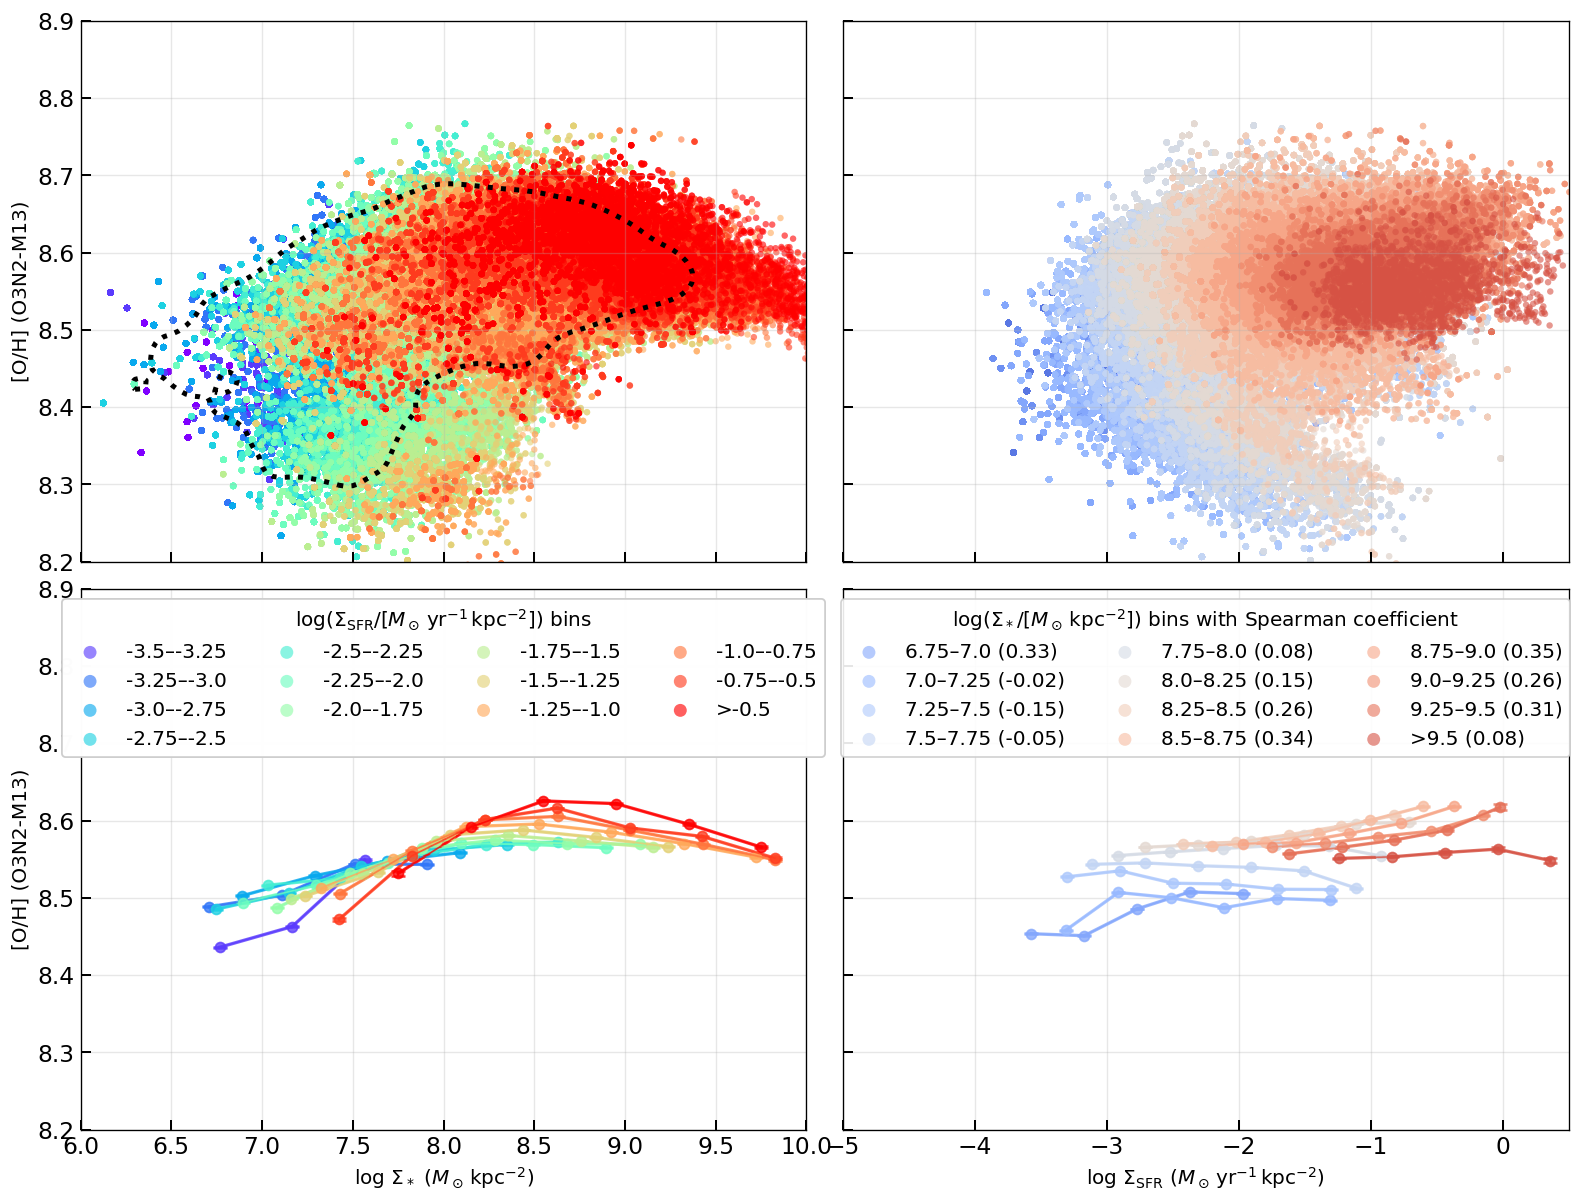


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 28 galaxies
Galaxies included: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [9]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
    # Using O3N2-M13 indicator only
    # 2x2 subplot layout:
    #   Top-left: rMZR scatter
    #   Top-right: Z_gas-Σ_SFR scatter
    #   Bottom-left: rMZR median trends
    #   Bottom-right: Z_gas-Σ_SFR median trends
    # ------------------------------------------------------------------
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    from astropy.io import fits

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    import scipy.stats as stats
    import scipy.ndimage as ndimage
    from scipy.optimize import curve_fit

    def load_maps_o3n2_m13(gal):
        """Load O3N2-M13 metallicity calibration for HII regions"""
        with fits.open(further_spatial_path(gal)) as h:
            sigM = h['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(further_gas_path(gal)) as h:
            sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            ha_sigma_obs = h['HA6562_SIGMA'].data
            ha_sigma_corr = h['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h else None
            if ha_sigma_corr is None:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in current further gas product')
            if ha_sigma_corr.shape != ha_sigma_obs.shape:
                raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {ha_sigma_corr.shape} vs SIGMA {ha_sigma_obs.shape}')
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        with fits.open(further_ew_path(gal, EW_FILE_SUFFIX)) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f'Missing {EW_HDU} in {gal}{EW_FILE_SUFFIX}')
            ew_ha = h_ew[EW_HDU].data
        ew_ha = align_map_to_shape(ew_ha, sigSFR_HII.shape, label=f"{gal} {EW_HDU}")
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR_HII = np.where(ew_mask, sigSFR_HII, np.nan)
        oh_o3n2_m13_HII = np.where(ew_mask, oh_o3n2_m13_HII, np.nan)
        return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

    def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
        """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
        x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
        for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
            in_bin = (x_data >= bin_start) & (x_data < bin_end)
            y_in_bin = y_data[in_bin]
            if len(np.unique(y_in_bin)) >= min_pixels:
                medians.append(np.median(y_in_bin))
                stds.append(np.std(y_in_bin))
                counts.append(len(y_in_bin))
                valid_centers.append(bin_centers[i])
                valid_bin_indices.append(i)
        return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

    def mzr_model(x, a, b, c):
        return a + b * (x - c) * np.exp(-(x - c))

    def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
        """Return mask for points inside the 95% density contour within given ranges."""
        mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
        if not np.any(mask_finite):
            empty_mask = np.zeros_like(x_vals, dtype=bool)
            return (empty_mask, None, None) if return_contour else empty_mask
        x = x_vals[mask_finite]
        y = y_vals[mask_finite]
        H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
        H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
        H_flat = np.sort(H_smooth.ravel())[::-1]
        H_cumsum = np.cumsum(H_flat)
        level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
        level_95 = H_flat[level_idx]
        x_centers = (xedges[:-1] + xedges[1:]) / 2
        y_centers = (yedges[:-1] + yedges[1:]) / 2
        X, Y = np.meshgrid(x_centers, y_centers)
        dx = (x_range[1] - x_range[0]) / nbins
        dy = (y_range[1] - y_range[0]) / nbins
        x_idx = (x - x_range[0]) / dx - 0.5
        y_idx = (y - y_range[0]) / dy - 0.5
        densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
        mask_local = densities >= level_95
        full_mask = np.zeros_like(x_vals, dtype=bool)
        full_mask[np.where(mask_finite)[0]] = mask_local
        if return_contour:
            return full_mask, level_95, (X, Y, H_smooth)
        return full_mask

    def plot_literature_mzr_fits(ax, show_legend=True):
        plot_data = []
        x_sanchez = np.linspace(7.05, 9.15, 200)
        a5, b5, c5 = 8.74, 0.013, 9.50
        y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
        plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
        x_bb = np.linspace(7., 8.9, 200)
        a2, b2, c2 = 8.55, 0.014, 9.14
        y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
        plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
        x_ef = np.linspace(6.5, 10.0, 200)
        a4, b4, c4 = 8.61, 0.008, 10.0
        y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
        plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
        for x, y, label, linestyle, color in plot_data:
            ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

    galaxies = physics_ready_galaxies(require_ew=True)
    excluded_galaxies = {'NGC4383'}
    included_galaxies = []
    all_logSigmaM_HII = []
    all_logSigmaSFR_HII = []
    all_oh_o3n2_m13_HII = []

    print("="*80)
    print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
    print("="*80)

    for gal in galaxies:
        if gal in excluded_galaxies:
            print(f"  {gal}: excluded from analysis")
            continue
        bin_file = further_spatial_path(gal)
        gas_file = further_gas_path(gal)
        if bin_file.exists() and gas_file.exists():
            included_galaxies.append(gal)
            (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
            common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
            print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
            all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
            all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
            all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        else:
            print(f"  {gal}: Data files not found")

    all_logSigmaM_HII = np.array(all_logSigmaM_HII)
    all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
    all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
    print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

    print("\n" + "="*80)
    print("STEP 2: Defining 14 SFR bins for rMZR")
    print("="*80)
    n_bins = 14
    sfr_bin_edges = [-np.inf, -3.5, -3.25, -3.0, -2.75, -2.5, -2.25, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, np.inf]
    bin_labels = ['<-3.5', '-3.5–-3.25', '-3.25–-3.0', '-3.0–-2.75', '-2.75–-2.5', '-2.5–-2.25',
                  '-2.25–-2.0', '-2.0–-1.75', '-1.75–-1.5', '-1.5–-1.25', '-1.25–-1.0', '-1.0–-0.75', '-0.75–-0.5', '>-0.5']
    for i, label in enumerate(bin_labels):
        print(f"  Bin {i+1}: {label}")
    colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

    print("\n" + "="*80)
    print("STEP 3: Defining 14 Σ_* bins for Z_gas-Σ_SFR")
    print("="*80)
    n_bins_sigmaM = 14
    sigmaM_bin_edges = [-np.inf, 6.5, 6.75, 7.0, 7.25, 7.5, 7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, np.inf]
    bin_labels_sigmaM = ['<6.5', '6.5–6.75', '6.75–7.0', '7.0–7.25', '7.25–7.5', '7.5–7.75',
                         '7.75–8.0', '8.0–8.25', '8.25–8.5', '8.5–8.75', '8.75–9.0', '9.0–9.25', '9.25–9.5', '>9.5']
    for i, label in enumerate(bin_labels_sigmaM):
        print(f"  Bin {i+1}: {label}")
    colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

    print("\n" + "="*80)
    print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
    print("="*80)
    common_ylim = (8.2, 8.9)
    x_range_rMZR = (6, 10)
    x_range_Zgas = (-5.0, 0.5)
    print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    oh_data_HII = all_oh_o3n2_m13_HII
    calib_name_HII = 'O3N2-M13'
    print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
    print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
    ax_rMZR_scatter = axes[0, 0]
    ax_Zgas_scatter = axes[0, 1]
    ax_rMZR_median = axes[1, 0]
    ax_Zgas_median = axes[1, 1]

    mask_95_all_rMZR, level_95_all_rMZR, contour_data_rMZR = compute_density_mask(all_logSigmaM_HII, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True)
    max_typical_yerr_rMZR = np.nan
    max_typical_yerr_Zgas = np.nan

    print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
    legend_handles_sfr, legend_labels_sfr = [], []
    valid_bins_rMZR = 0
    for i in range(n_bins):
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
        n_pixels_HII = np.sum(in_bin_HII)
        if n_pixels_HII >= 10:
            x_bin_all = all_logSigmaM_HII[in_bin_HII]
            y_bin_all = oh_data_HII[in_bin_HII]
            scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
            mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
            x_bin = x_bin_all[mask_95_bin]
            y_bin = y_bin_all[mask_95_bin]
            if len(x_bin) >= 10:
                mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
                if len(mass_centers_HII) >= 3:
                    legend_handles_sfr.append(scatter_hii)
                    legend_labels_sfr.append(bin_labels[i])
                    yerr_HII = stds_HII / np.sqrt(counts_HII)
                    typical_yerr = np.nanmedian(yerr_HII)
                    print(f"    rMZR bin {i+1} {bin_labels[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                    if np.isfinite(typical_yerr):
                        max_typical_yerr_rMZR = np.nanmax([max_typical_yerr_rMZR, typical_yerr])
                    ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                    for j in range(len(valid_bin_indices_HII) - 1):
                        current_bin_idx = valid_bin_indices_HII[j]
                        next_bin_idx = valid_bin_indices_HII[j + 1]
                        if next_bin_idx - current_bin_idx == 1:
                            ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
                    valid_bins_rMZR += 1

    if contour_data_rMZR is not None and level_95_all_rMZR is not None:
        ax_rMZR_scatter.contour(contour_data_rMZR[0], contour_data_rMZR[1], contour_data_rMZR[2].T, levels=[level_95_all_rMZR], colors='k', linewidths=3, linestyles=':')
    ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_rMZR_scatter.grid(True, alpha=0.3)
    ax_rMZR_scatter.set_xlim(*x_range_rMZR)
    ax_rMZR_scatter.set_ylim(common_ylim)
    ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_rMZR_median.grid(True, alpha=0.3)
    ax_rMZR_median.set_xlim(*x_range_rMZR)
    ax_rMZR_median.set_ylim(common_ylim)
    legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins', title_fontsize=12)
    legend1_handles = getattr(legend1, "legend_handles", None)
    if legend1_handles is None:
        legend1_handles = getattr(legend1, "legendHandles", [])
    for handle in legend1_handles:
        try:
            handle.set_sizes([60])
        except Exception:
            pass
    ax_rMZR_median.add_artist(legend1)
    # if np.isfinite(max_typical_yerr_rMZR):
    #     ax_rMZR_median.errorbar(x_range_rMZR[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_rMZR, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
    print(f"  rMZR valid bins: {valid_bins_rMZR}")

    print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
    legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
    valid_bins_Zgas = 0
    for i in range(n_bins_sigmaM):
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
        n_pixels_HII = np.sum(in_bin_HII)
        if n_pixels_HII >= 10:
            x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
            y_bin_all = oh_data_HII[in_bin_HII]
            scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
            mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
            x_bin = x_bin_all[mask_95_bin]
            y_bin = y_bin_all[mask_95_bin]
            spearman_text = "N/A"
            if len(x_bin) > 1:
                y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
                x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
                mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
                x_clipped = x_bin[mask_clip]
                y_clipped = y_bin[mask_clip]
                sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
                if len(sfr_centers_HII) >= 3:
                    if len(x_clipped) > 10:
                        corr, _ = stats.spearmanr(x_clipped, y_clipped)
                        spearman_text = f"{corr:.2f}"
                    legend_handles_sigmaM.append(scatter_hii)
                    legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")
                    yerr_HII = stds_HII / np.sqrt(counts_HII)
                    typical_yerr = np.nanmedian(yerr_HII)
                    print(f"    Zgas-ΣSFR bin {i+1} {bin_labels_sigmaM[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                    if np.isfinite(typical_yerr):
                        max_typical_yerr_Zgas = np.nanmax([max_typical_yerr_Zgas, typical_yerr])
                    ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                    for j in range(len(valid_bin_indices_HII) - 1):
                        current_bin_idx = valid_bin_indices_HII[j]
                        next_bin_idx = valid_bin_indices_HII[j + 1]
                        if next_bin_idx - current_bin_idx == 1:
                            ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                    valid_bins_Zgas += 1


    ax_Zgas_scatter.grid(True, alpha=0.3)
    ax_Zgas_scatter.set_xlim(*x_range_Zgas)
    ax_Zgas_scatter.set_ylim(common_ylim)
    ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_Zgas_median.grid(True, alpha=0.3)
    ax_Zgas_median.set_xlim(*x_range_Zgas)
    ax_Zgas_median.set_ylim(common_ylim)
    legend2 = ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient', title_fontsize=12)
    legend2_handles = getattr(legend2, "legend_handles", None)
    if legend2_handles is None:
        legend2_handles = getattr(legend2, "legendHandles", [])
    for handle in legend2_handles:
        try:
            handle.set_sizes([60])
        except Exception:
            pass
    # if np.isfinite(max_typical_yerr_Zgas):
    #     ax_Zgas_median.errorbar(x_range_Zgas[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_Zgas, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
    print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_EW.png', dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_EW.pdf', bbox_inches='tight')
    plt.show()

    print("\n" + "="*80)
    print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
    print("="*80)
    print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
    print(f"Galaxies included: {', '.join(included_galaxies)}")
    print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
    print("\nPanel summary:")
    print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
    print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
    print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
    print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
    print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
else:
    print("Skipped copied previous-project analysis cell 15: no nested *_further mass/SFR/OH+EW products are ready yet.")


## Fixed-galaxy-color plot recreations

These four cells use the fixed MAUVE galaxy palette for source cells 15, 17, 26, and 28.

### Source cell 15 recreated with fixed galaxy colors

Cell 15 fixed-galaxy-color map panel: 29 galaxies


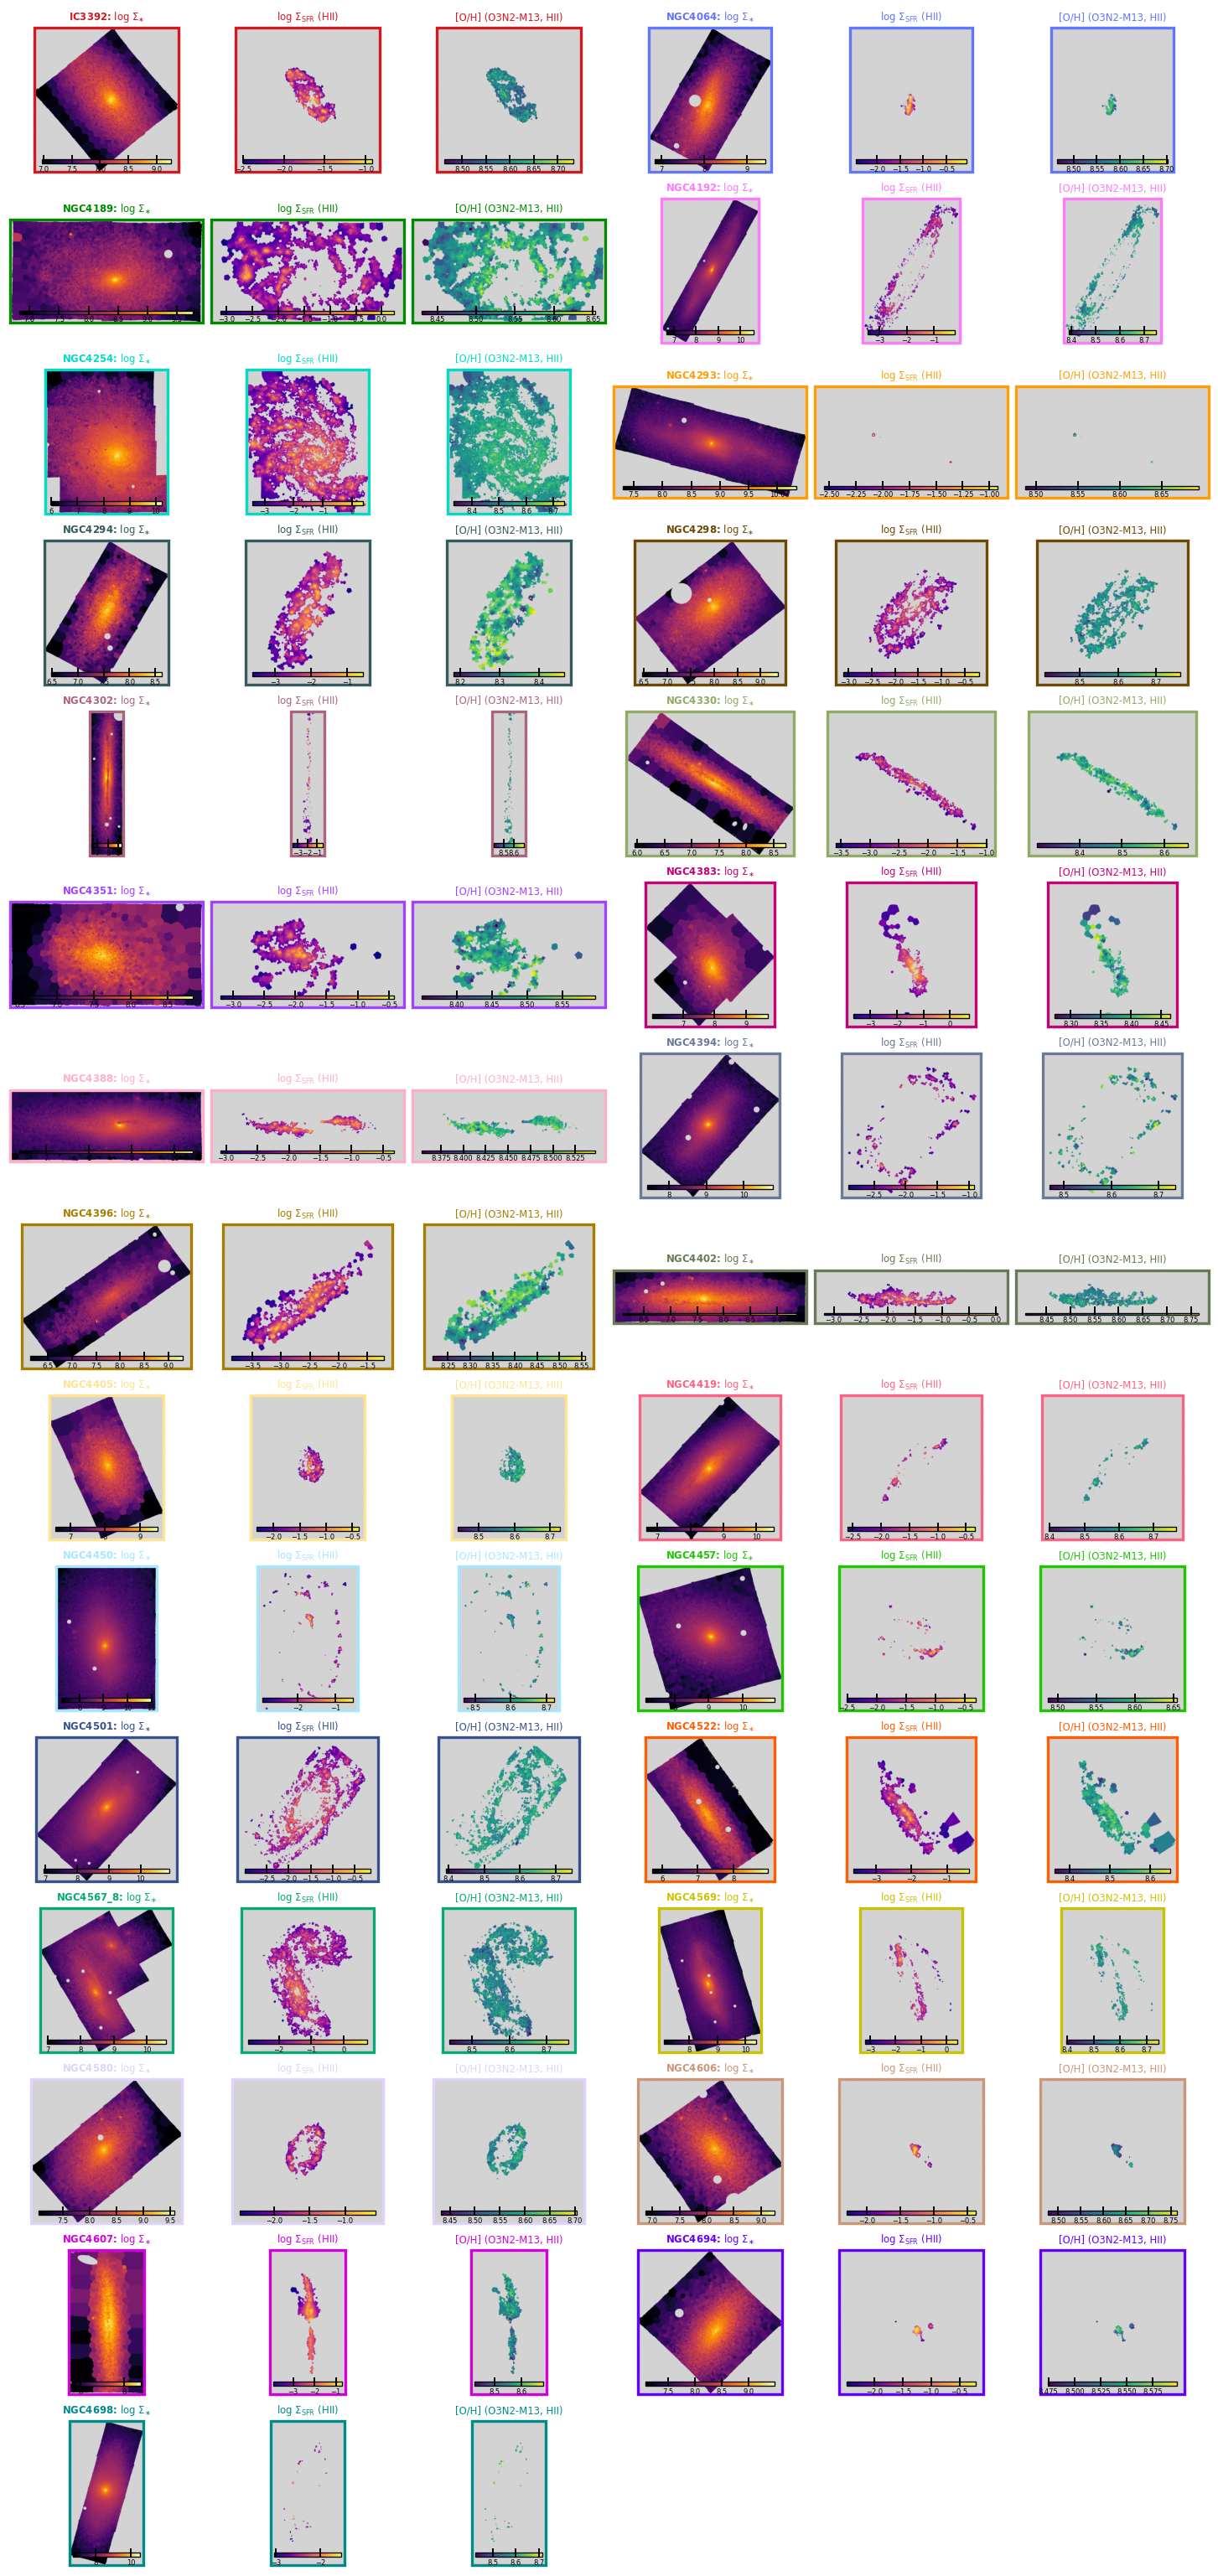

In [10]:
if old_paper_cells_ready(require_ew=True):
    # --------------------------------------------------------------
    # Source cell 15 recreated with fixed galaxy identity colors.
    # Physical map colormaps are preserved; galaxy color is used for
    # the galaxy title and panel frame so it does not replace map values.
    # --------------------------------------------------------------
    import math
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    from matplotlib.patches import Rectangle
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    galaxies = ordered_galaxies_by_fixed_palette(physics_ready_galaxies(require_ew=True))
    ngal = len(galaxies)
    print(f"Cell 15 fixed-galaxy-color map panel: {ngal} galaxies")

    def load_maps_hii_for_color_panel(gal):
        maps = load_common_maps_for_galaxy(gal, include_c20=False, require_sigma_mask=True)
        logSigmaM = maps["logSigmaM"]
        sigSFR_HII = maps["logSigmaSFR"]
        oh_o3n2m13_HII = maps["oh_m13"]
        ew_ha = maps["ew_ha"]
        ha_sigma = maps["ha_sigma"]
        mass_mask = np.isfinite(logSigmaM)
        hii_mask = (
            np.isfinite(sigSFR_HII)
            & np.isfinite(oh_o3n2m13_HII)
            & np.isfinite(ew_ha)
            & (ew_ha > EW_MIN)
            & np.isfinite(ha_sigma)
            & (ha_sigma < 45.0)
        )
        return (
            np.where(mass_mask, logSigmaM, np.nan),
            np.where(hii_mask, sigSFR_HII, np.nan),
            np.where(hii_mask, oh_o3n2m13_HII, np.nan),
        )

    def frame_axis_with_galaxy_color(ax, gal):
        ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor=galaxy_color(gal), linewidth=2.0, clip_on=False))

    nrows = max(1, math.ceil(ngal / 2))
    fig = plt.figure(figsize=(12, max(3.0, 1.7 * nrows)), constrained_layout=True)
    gs = GridSpec(nrows=nrows, ncols=6, figure=fig, width_ratios=[1, 1, 1, 1, 1, 1], wspace=0.00, hspace=0.00)

    for idx, gal in enumerate(galaxies):
        row = idx // 2
        blk = idx % 2
        col0 = blk * 3
        gal_color = galaxy_color(gal)
        logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c = load_maps_hii_for_color_panel(gal)

        axM = fig.add_subplot(gs[row, col0])
        cmap_M = plt.cm.inferno.copy(); cmap_M.set_bad('lightgray')
        imM = axM.imshow(logSigmaM_c, origin='lower', cmap=cmap_M)
        axM.set_title(rf'{gal}: $\log\,\Sigma_{{\ast}}$', fontsize=7, color=gal_color, fontweight='bold')
        axM.axis('off')
        frame_axis_with_galaxy_color(axM, gal)
        caxM = inset_axes(axM, width='90%', height='3%', loc='lower center', borderpad=0.6)
        fig.colorbar(imM, cax=caxM, orientation='horizontal')
        caxM.tick_params(labelsize=5, pad=1)

        axS = fig.add_subplot(gs[row, col0 + 1])
        cmap_S = plt.cm.plasma.copy(); cmap_S.set_bad('lightgray')
        imS = axS.imshow(sigSFR_HII_c, origin='lower', cmap=cmap_S)
        axS.set_title(r'$\log\,\Sigma_{\mathrm{SFR}}$ (HII)', fontsize=7, color=gal_color)
        axS.axis('off')
        frame_axis_with_galaxy_color(axS, gal)
        caxS = inset_axes(axS, width='90%', height='3%', loc='lower center', borderpad=0.6)
        fig.colorbar(imS, cax=caxS, orientation='horizontal')
        caxS.tick_params(labelsize=5, pad=1)

        axOH = fig.add_subplot(gs[row, col0 + 2])
        cmap_OH = plt.cm.viridis.copy(); cmap_OH.set_bad('lightgray')
        imOH = axOH.imshow(oh_o3n2m13_c, origin='lower', cmap=cmap_OH)
        axOH.set_title(r'[O/H] (O3N2-M13, HII)', fontsize=7, color=gal_color)
        axOH.axis('off')
        frame_axis_with_galaxy_color(axOH, gal)
        caxOH = inset_axes(axOH, width='90%', height='3%', loc='lower center', borderpad=0.6)
        fig.colorbar(imOH, cax=caxOH, orientation='horizontal')
        caxOH.tick_params(labelsize=5, pad=1)

    plt.show()
else:
    print("Skipped source cell 15 fixed-color recreation: no nested *_further mass/SFR/OH+EW products are ready yet.")


### Source cell 17 recreated with fixed galaxy colors

Using fixed MAUVE_GALAXY_GLASBEY_PACKAGE_40 colors for source cell 17 recreation.
Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range (95%): 7.997 to 8.788
  Global Δlog(Σ_SFR) axis limits: ±0.824
  Global Δ[O/H] axis limits: ±0.159
  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):
    Bin 01 (8.06): n=941, r=N/A (no trend or too few in 3σ)
    Bin 02 (8.2

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_81152/1665906249.py:477: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


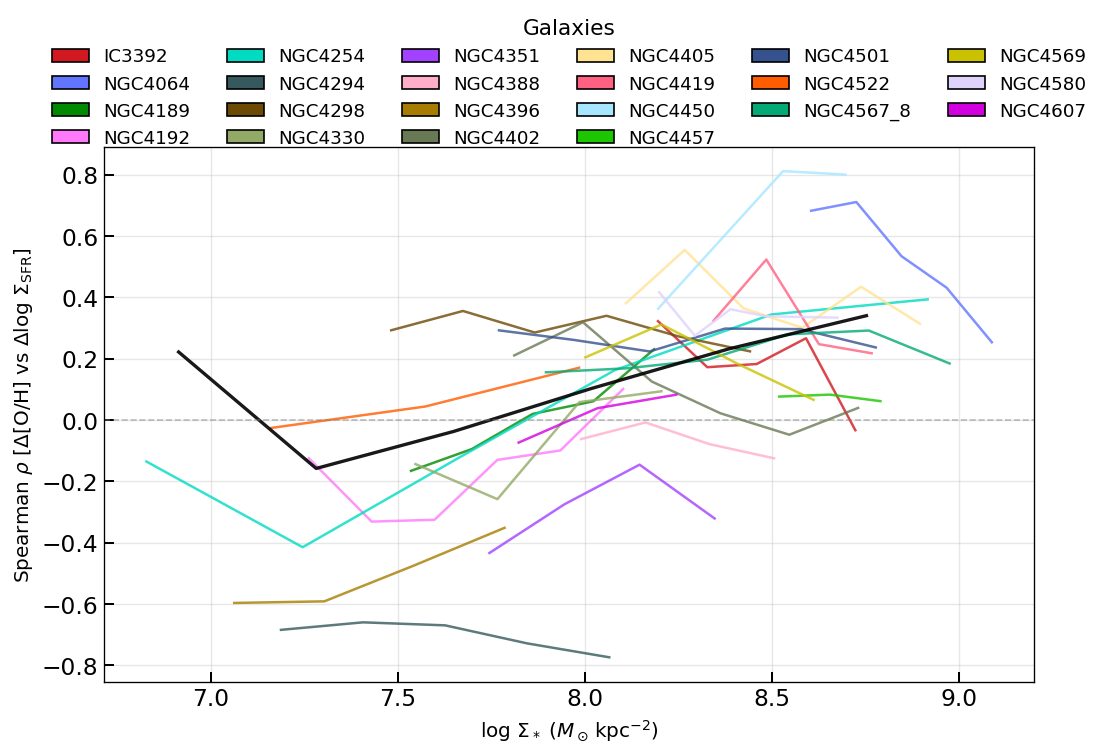

In [11]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Source cell 17 recreated with fixed galaxy colors: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins
    # For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
    # Spearman rho uses only points inside 95% contour and only if trend exists
    # ------------------------------------------------------------------
    from pathlib import Path
    from astropy.io import fits

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import BoundaryNorm
    import matplotlib.gridspec as gridspec
    from scipy.stats import spearmanr
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    # ------------------------------------------------------------------
    # Helper: read the required maps
    # ------------------------------------------------------------------
    def load_maps(gal):
        spatial_path = further_spatial_path(gal)
        gas_path = further_gas_path(gal)
        ew_path = further_ew_path(gal, EW_FILE_SUFFIX)

        if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
            raise FileNotFoundError(f'Required FITS files for {gal} not found.')

        with fits.open(spatial_path) as h_spatial:
            sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(gas_path) as h_gas:
            sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
            ha_sigma_obs = h_gas['HA6562_SIGMA'].data
            ha_sigma_corr = h_gas['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h_gas else None
            if ha_sigma_corr is None:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_path}')
            if ha_sigma_corr.shape != ha_sigma_obs.shape:
                raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {ha_sigma_corr.shape} vs SIGMA {ha_sigma_obs.shape}')
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            if 'O_H_O3N2_M14_HII' in h_gas:
                oh_map = h_gas['O_H_O3N2_M14_HII'].data
                indicator_name = 'O3N2-M14'
            elif 'O_H_O3N2_M13_HII' in h_gas:
                print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
                oh_map = h_gas['O_H_O3N2_M13_HII'].data
                indicator_name = 'O3N2-M13'
            else:
                available = [hdu.name for hdu in h_gas]
                raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        with fits.open(ew_path) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f"Missing {EW_HDU} in {ew_path}")
            ew_ha = h_ew[EW_HDU].data
        ew_ha = align_map_to_shape(ew_ha, sigSFR.shape, label=f"{gal} {EW_HDU}")
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR = np.where(ew_mask, sigSFR, np.nan)
        oh_map = np.where(ew_mask, oh_map, np.nan)
        return sigM, sigSFR, oh_map, indicator_name

    # ------------------------------------------------------------------
    # Helper: calculate binned statistics with unique-count requirement
    # ------------------------------------------------------------------
    def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
        """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
        x_data = np.asarray(x_data)
        y_data = np.asarray(y_data)

        finite = np.isfinite(x_data) & np.isfinite(y_data)
        if np.sum(finite) == 0:
            return np.array([]), np.array([]), np.array([]), np.array([])

        x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
        if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
            return np.array([]), np.array([]), np.array([]), np.array([])

        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
        if bin_edges.size < 2:
            return np.array([]), np.array([]), np.array([]), np.array([])

        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        medians = []
        stds = []
        counts = []
        valid_centers = []

        for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
            in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
            if np.sum(in_bin) == 0:
                continue

            y_in_bin = y_data[in_bin]
            if len(np.unique(y_in_bin)) >= min_unique:
                medians.append(np.nanmedian(y_in_bin))
                stds.append(np.nanstd(y_in_bin))
                counts.append(len(y_in_bin))
                valid_centers.append(bin_centers[i])

        return (np.array(valid_centers), np.array(medians),
                np.array(stds), np.array(counts))

    # ------------------------------------------------------------------
    # Galaxy list and color map (reserve color for excluded galaxy)
    # ------------------------------------------------------------------
    all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
    all_rho_values = []     # Spearman rho (per-galaxy)
    all_galaxy_indices = []

    # Also store all spaxels across galaxies to compute a global trend
    global_sigM_list = []
    global_sigSFR_list = []
    global_oh_list = []
    global_gal_index_list = []

    # Build full galaxy list from available FITS files (including excluded)
    galaxies_all = physics_ready_galaxies(require_ew=True)
    excluded_galaxies = {'NGC4383'}

    # Build galaxy -> fixed MAUVE color mapping over ALL galaxies (so excluded keeps its color)
    galaxy_color_dict = {gal: galaxy_color(gal) for gal in galaxies_all}
    print(f"Using fixed {FIXED_GALAXY_PALETTE_NAME} colors for source cell 17 recreation.")

    # Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
    galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

    print("=" * 80)
    print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
    print("All galaxies (for color assignment):", ", ".join(galaxies_all))
    print("Galaxies used in this analysis:", ", ".join(galaxies))
    print("=" * 80)

    # ------------------------------------------------------------------
    # Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
    # and collect global spaxels for combined trend
    # ------------------------------------------------------------------
    for gal_index, gal in enumerate(galaxies):
        print(f"\nProcessing {gal} ...")
        try:
            sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
        except Exception as e:
            print(f"  Skipping {gal}: {e}")
            continue

        valid_sfr = np.isfinite(sigSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_sigM = np.isfinite(sigM)
        valid_all = valid_sfr & valid_oh & valid_sigM

        if np.sum(valid_all) == 0:
            print("  No valid pixels.")
            continue

        # Collect into global arrays for combined analysis
        global_sigM_list.append(sigM[valid_all].ravel())
        global_sigSFR_list.append(sigSFR[valid_all].ravel())
        global_oh_list.append(oh_o3n2_map[valid_all].ravel())
        global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

        # 1. Define 6 Σ_* bins for this galaxy (spanning 95% population)
        n_bins = 6
        sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
        sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
        sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
        sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

        # 2. Global symmetric limits for this galaxy (for reference / consistency)
        global_max_abs_sfr = 0
        global_max_abs_oh = 0
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

            if np.sum(bin_mask) > 0:
                sfr_bin = sigSFR[bin_mask]
                oh_bin = oh_o3n2_map[bin_mask]

                sfr_offset = sfr_bin - np.mean(sfr_bin)
                oh_offset = oh_bin - np.mean(oh_bin)

                if np.any(np.isfinite(sfr_offset)):
                    global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
                if np.any(np.isfinite(oh_offset)):
                    global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

        print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
        print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
        print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

        # 3. Compute Spearman rho in each Σ_* bin using 3-sigma clipping on unique data (per galaxy)
        print("  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):")
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

            n_pixels = np.sum(bin_mask)

            if n_pixels <= 0:
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
                continue

            # Values in this Σ_* bin
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            # Offsets within this bin
            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

            if np.sum(valid_corr) <= 2:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
                continue

            # ------------------------------------------------------------------
            # Calculate 3-sigma clipping mask on unique valid data
            # ------------------------------------------------------------------
            sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 0:
                # Get unique valid data using np.unique
                sfr_data = sfr_offset[valid_corr]
                oh_data = oh_offset[valid_corr]
            
                sfr_unique = np.unique(sfr_data)
                oh_unique = np.unique(oh_data)
            
                # Calculate mean and std on unique values
                x_mean = np.mean(sfr_unique)
                x_std = np.std(sfr_unique)
                y_mean = np.mean(oh_unique)
                y_std = np.std(oh_unique)
            
                # 3-sigma bounds
                x_lower = x_mean - 3 * x_std
                x_upper = x_mean + 3 * x_std
                y_lower = y_mean - 3 * y_std
                y_upper = y_mean + 3 * y_std
            
                # Apply 3-sigma clipping to all data points
                within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                                (oh_data >= y_lower) & (oh_data <= y_upper)
                sigma_clip_mask[valid_corr] = within_3sigma

            # ------------------------------------------------------------------
            # Median trend using only points within 3-sigma
            # ------------------------------------------------------------------
            x_trend = sfr_offset[sigma_clip_mask]
            y_trend = oh_offset[sigma_clip_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            # Require at least 2 median-trend points for a valid trend
            has_trend = centers.size >= 3

            # ------------------------------------------------------------------
            # Spearman rho: only for points within 3-sigma and only if trend exists
            # ------------------------------------------------------------------
            if has_trend and np.sum(sigma_clip_mask & valid_corr) > 2:
                try:
                    spearman_rho, spearman_p = spearmanr(sfr_offset[sigma_clip_mask & valid_corr],
                                                    oh_offset[sigma_clip_mask & valid_corr])
                    print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})")
                except Exception:
                    spearman_rho = np.nan
                    print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
            else:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 3σ)")

            # Store only valid rho values
            if np.isfinite(spearman_rho):
                all_bin_centers.append(sigmaM_bin_centers[i])
                all_rho_values.append(spearman_rho)
                all_galaxy_indices.append(gal_index)

    # ------------------------------------------------------------------
    # Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
    # ------------------------------------------------------------------
    if global_sigM_list:
        global_sigM = np.concatenate(global_sigM_list)
        global_sigSFR = np.concatenate(global_sigSFR_list)
        global_oh = np.concatenate(global_oh_list)
    else:
        global_sigM = np.array([])
        global_sigSFR = np.array([])
        global_oh = np.array([])

    # ------------------------------------------------------------------
    # Convert collected per-galaxy Spearman rho data to arrays
    # ------------------------------------------------------------------
    all_bin_centers = np.array(all_bin_centers)
    all_rho_values = np.array(all_rho_values)
    all_galaxy_indices = np.array(all_galaxy_indices)

    print("\n" + "=" * 80)
    print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
    print("=" * 80)

    # ------------------------------------------------------------------
    # Compute combined Spearman rho vs Σ_* over all galaxies (same method)
    # ------------------------------------------------------------------
    global_bin_centers = []
    global_rho_values = []

    if global_sigM.size > 0:
        # Define 6 Σ_* bins for the combined sample (spanning 95% population)
        n_bins_global = 6
        sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
        sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
        sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
        sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

        print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
        for i in range(n_bins_global):
            if i == 0:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
            elif i == n_bins_global - 1:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
            else:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

            n_pix_g = np.sum(bin_mask_g)
            if n_pix_g <= 0:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
                continue

            sfr_bin_g = global_sigSFR[bin_mask_g]
            oh_bin_g = global_oh[bin_mask_g]

            sfr_mean_g = np.mean(sfr_bin_g)
            oh_mean_g = np.mean(oh_bin_g)

            sfr_off_g = sfr_bin_g - sfr_mean_g
            oh_off_g = oh_bin_g - oh_mean_g

            valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
            if np.sum(valid_corr_g) <= 2:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
                continue

            # ------------------------------------------------------------------
            # Calculate 3-sigma clipping mask on unique valid data (global)
            # ------------------------------------------------------------------
            sigma_clip_mask_global = np.zeros_like(valid_corr_g, dtype=bool)
            if np.sum(valid_corr_g) > 0:
                sfr_data_g = sfr_off_g[valid_corr_g]
                oh_data_g = oh_off_g[valid_corr_g]
            
                sfr_unique_g = np.unique(sfr_data_g)
                oh_unique_g = np.unique(oh_data_g)
            
                x_mean_g = np.mean(sfr_unique_g)
                x_std_g = np.std(sfr_unique_g)
                y_mean_g = np.mean(oh_unique_g)
                y_std_g = np.std(oh_unique_g)
            
                x_lower_g = x_mean_g - 3 * x_std_g
                x_upper_g = x_mean_g + 3 * x_std_g
                y_lower_g = y_mean_g - 3 * y_std_g
                y_upper_g = y_mean_g + 3 * y_std_g
            
                within_3sigma_g = (sfr_data_g >= x_lower_g) & (sfr_data_g <= x_upper_g) & \
                                  (oh_data_g >= y_lower_g) & (oh_data_g <= y_upper_g)
                sigma_clip_mask_global[valid_corr_g] = within_3sigma_g

            x_trend_g = sfr_off_g[sigma_clip_mask_global]
            y_trend_g = oh_off_g[sigma_clip_mask_global]

            centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                            bin_width=0.2,
                                                                            min_unique=20)

            has_trend_g = centers_g.size >= 3

            if has_trend_g and np.sum(sigma_clip_mask_global & valid_corr_g) > 2:
                try:
                    rho_g, p_g = spearmanr(sfr_off_g[sigma_clip_mask_global & valid_corr_g],
                                         oh_off_g[sigma_clip_mask_global & valid_corr_g])
                    global_bin_centers.append(sigmaM_centers_g[i])
                    global_rho_values.append(rho_g)
                    print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})")
                except Exception:
                    print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")
            else:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 3σ)")

    global_bin_centers = np.array(global_bin_centers)
    global_rho_values = np.array(global_rho_values)

    # ------------------------------------------------------------------
    # Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
    # and an additional combined (all galaxies) trend in black
    # ------------------------------------------------------------------
    if len(all_rho_values) > 0:
    
        galaxy_indices_unique = np.unique(all_galaxy_indices)
    
        # Create figure with main axis and a thin top axis for legend
        fig = plt.figure(figsize=(10, 7))
        gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
        legend_ax = fig.add_subplot(gs[0, 0])
        ax = fig.add_subplot(gs[1, 0])
        legend_ax.axis('off')
    
        plotted_galaxies = [] # Keep track of which galaxies are actually plotted
    
        # Plot Spearman rho vs Σ_* for each galaxy
        for idx in galaxy_indices_unique:
            mask = all_galaxy_indices == idx
            gal_name = galaxies[idx]
            color = galaxy_color_dict[gal_name]
        
            # Sort by Σ_* so lines are not scrambled
            x_vals = all_bin_centers[mask]
            y_vals = all_rho_values[mask]
        
            # Filter: skip if only 1 data point
            if len(x_vals) <= 2:
                continue
            
            plotted_galaxies.append(gal_name)
        
            order = np.argsort(x_vals)
            x_sorted = x_vals[order]
            y_sorted = y_vals[order]
        
            ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
            # No per-galaxy scatter points: line-only trend summary for this 1D diagnostic.
    
        # Add combined trend (all galaxies together) in black (no legend entry)
        if global_rho_values.size > 2:
            order_g = np.argsort(global_bin_centers)
            ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                    color='black', linewidth=2.0, alpha=0.9, linestyle='-')
            # No global scatter points: black line is the pooled trend summary.
    
        # Axis formatting
        ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
        # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
        ax.grid(True, alpha=0.3)
    
        # ------------------------------------------------------------------
        # Galaxy legend at the top using dummy patches (excluding NGC4383)
        # ------------------------------------------------------------------
        legend_elements = [
            Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
            for gal in plotted_galaxies
        ]
        if len(plotted_galaxies) > 0:
            legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(plotted_galaxies), 6),
                            frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
        plt.tight_layout()
        # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383_EW.png',
                    # dpi=600, bbox_inches='tight')
        # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383_EW.pdf',
                    # bbox_inches='tight')
        plt.show()
    else:
        print("No valid Spearman rho values to plot.")
else:
    print("Skipped copied previous-project analysis cell 6: no nested *_further mass/SFR/OH+EW products are ready yet.")


In [19]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Offset relation (Δ[O/H] vs Δlog Σ_SFR) 95% population contours by galaxy
    # Reusing the data collection logic from the previous cell,
    # but visualizing the 2D distribution instead of 1D Spearman lines.
    # ------------------------------------------------------------------
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    galaxies_all = physics_ready_galaxies(require_ew=True)
    excluded_galaxies = {'NGC4383'}
    galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

    print("=" * 80)
    print(f"Offset relations 95% contours (excluding: {excluded_galaxies})")
    print("=" * 80)

    per_galaxy_offsets = {}
    global_sfr_off = []
    global_oh_off = []
    
    global_max_abs_sfr = 0.0
    global_max_abs_oh = 0.0

    for gal_index, gal in enumerate(galaxies):
        try:
            sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
        except Exception as e:
            continue

        valid_sfr = np.isfinite(sigSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_sigM = np.isfinite(sigM)
        valid_all = valid_sfr & valid_oh & valid_sigM

        if np.sum(valid_all) == 0:
            continue

        # Define 6 Σ_* bins for this galaxy (spanning 95% population)
        n_bins = 6
        sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
        sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
        sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

        gal_sfr_off = []
        gal_oh_off = []

        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

            if np.sum(bin_mask) > 0:
                sfr_bin = sigSFR[bin_mask]
                oh_bin = oh_o3n2_map[bin_mask]

                sfr_offset = sfr_bin - np.mean(sfr_bin)
                oh_offset = oh_bin - np.mean(oh_bin)
                
                gal_sfr_off.append(sfr_offset)
                gal_oh_off.append(oh_offset)

                if np.any(np.isfinite(sfr_offset)):
                    global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
                if np.any(np.isfinite(oh_offset)):
                    global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))
        
        print(f'{gal}: len(gal_sfr_off)={len(gal_sfr_off)}')
        if gal_sfr_off:
            gal_sfr_off_concat = np.concatenate(gal_sfr_off)
            gal_oh_off_concat = np.concatenate(gal_oh_off)
            
            valid_corr = np.isfinite(gal_sfr_off_concat) & np.isfinite(gal_oh_off_concat)
            if np.sum(valid_corr) > 0:
                per_galaxy_offsets[gal] = {
                    'sfr_off': gal_sfr_off_concat[valid_corr],
                    'oh_off': gal_oh_off_concat[valid_corr]
                }
                global_sfr_off.append(gal_sfr_off_concat[valid_corr])
                global_oh_off.append(gal_oh_off_concat[valid_corr])

    if not per_galaxy_offsets:
        print("No valid offset data to plot.")
    else:
        fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
        
        all_sfr = np.concatenate(global_sfr_off)
        all_oh = np.concatenate(global_oh_off)
        
        sfr_99 = np.nanpercentile(np.abs(all_sfr), 99) * 1.5
        oh_99 = np.nanpercentile(np.abs(all_oh), 99) * 1.5
        xlim_off = (-sfr_99, sfr_99)
        ylim_off = (-oh_99, oh_99)

        plotted_galaxies = []
        
        # Global 95% contour
        c_global = plot_closed_95_contour_for_color(
            ax, all_sfr, all_oh, x_range=xlim_off, y_range=ylim_off,
            color='black', min_points=50, linewidth=3.0, alpha=0.9
        )

        for gal, data in per_galaxy_offsets.items():
            color = galaxy_color_dict[gal]
            c = plot_closed_95_contour_for_color(
                ax, data['sfr_off'], data['oh_off'], x_range=xlim_off, y_range=ylim_off,
                color=color, min_points=50, linewidth=2.0, alpha=0.85
            )
            if c is not None:
                plotted_galaxies.append(gal)

        ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
        
        ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (\mathrm{M}_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=16)
        ax.set_ylabel(r'$\Delta[\mathrm{O/H}]$', fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        ax.set_xlim(xlim_off)
        ax.set_ylim(ylim_off)
        ax.grid(True, alpha=0.3)

        legend_elements = [Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal) for gal in plotted_galaxies]
        legend_elements.append(Line2D([0], [0], color='black', linewidth=3.0, label='Pooled 95% contour'))
        
        ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False, fontsize=12)
        
        plt.show()
        print(f"Galaxies with plotted contours: {', '.join(plotted_galaxies)}")
else:
    print("Skipped offset relations contour plot: products not ready.")


Offset relations 95% contours (excluding: {'NGC4383'})
No valid offset data to plot.
